# Workstream 1: Data Preprocessing, Indicator Selection & EDA

**Target:** Total GHG excl LULUCF (Mt CO₂e)
<br> **Window:** 2000–2024
<br> **Panel:** 135 countries (data-driven completeness gates)
<br> **Framework:** STIRPAT 
<br> **Output:** `WS1_Panel_Imputed.csv` (for WS2 modelling)

| Step | What | Output |
|-------|------|--------|
| **1 Load Raw Data** | (A) Load WDI CSV, keep needed columns; <br>(B) Filter to aggregate-total rows; <br>(C) Special Treatment for Urban% indicator code | Raw panel |
| **2 Data Quality Gates** | (A) Keep **Countries** with Sufficient Data (≥80% target, ≥50% predictors); <br>(B) Grade each **indicator** by Completeness (GREEN / AMBER / RED); <br>(C) Remove Unsuitable Indicators | 135 countries, predictor pool |
| **3 Reshape Dataframe & Fill Gaps** | (A) Pivot into country×year table; <br>(B) Fill gaps i.e. missing data (interpolation, forward fill, extrapolation); <br>(C) Add COVID dummy (2020–2021) | `Panel_Df` |
| **4 Screening & Indicator Selection** | (A) Correlation heatmaps: Identify which predictors move with GHG; <br>(B) Bar chart: Apply abs(r) ≥ 0.30 cutoff; <br>(C) Three screens indicator selection (Correlation → VIF → STIRPAT); <br>(D) Kaya validation regression | 7 predictors + target |
| **5 Focused EDA** | (A) Scatter plots (final predictors vs GHG); <br>(B) Time trends (2000–2024); <br>(C) GHG composition; <br>(D) COVID disruption check; <br>(E) Outlier scan; <br>(F) Country clustering | Charts in Output_WS1 |
| **6 Export** | (A) Shape, stationarity, correlation checks; <br>(B) Save final panel | `WS1_Panel_Imputed.csv` |

## Working Directory
Set `Drive_Path` to your local project folder. (only things need to change)
<br> All other paths derive from it.

In [145]:
from pathlib import Path
import os

## Only change this line: 
Drive_Path = Path.home() / "Desktop/MASAHKT2026/Model"

In [146]:
# Define subdirectories
Data_Path = Drive_Path / "Data"
Code_Path = Drive_Path / "Code"
Output_Path = Drive_Path / "Output"
Output_WS1 = Output_Path / "Output_WS1"
Output_WS2 = Output_Path / "Output_WS2"
Output_WS3 = Output_Path / "Output_WS3"
Output_WS4 = Output_Path / "Output_WS4"

# Define input file name
WDI_Filename = 'WB_WDI_WIDEF.csv'
# Source note for WDI data (Chart footnote)
WDI_Source = 'Source: World Bank WDI (Wide Format), accessed 2026-04-26' 

# Create folders if they don't exist
for p in [Data_Path, Code_Path, Output_Path,Output_WS1, Output_WS2, Output_WS3, Output_WS4]:
    p.mkdir(parents=True, exist_ok=True)

## Setup
* Import libraries; 
* Set constants; and 
* Define 25 candidate WDI indicators: 14 potential predictors + 11 emissions/target variables used for context and decomposition

An **emissions-exclusion set** is also defined here:  
* CO₂, methane, and N₂O are components of Total GHG (the target), so they are excluded from the predictor list to prevent circular prediction.

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # for plotting
import seaborn as sns
from scipy import stats # for statistical tests
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import cdist
from statsmodels.tsa.stattools import adfuller  #for regression
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 150, 'font.family': 'sans-serif'})
sns.set_theme(style='whitegrid', font_scale=0.9)

# Analysis window 
Years     = [str(y) for y in range(2000, 2025)]
Int_Years = list(range(2000, 2025))

# Target variable 
Target = 'WB_WDI_EN_GHG_ALL_MT_CE_AR5'

# Emissions exclusion set 
# - Sub-components and derivatives of Total GHG
# - Total GHG = CO2 + CH4 + N2O + F-gases.
# These are excluded from predictors to avoid circular prediction

Emissions_Exclude = {
    Target,
    'WB_WDI_EN_GHG_CO2_MT_CE_AR5',       # CO2 — subset of target
    'WB_WDI_EN_GHG_CH4_MT_CE_AR5',       # methane — subset of target
    'WB_WDI_EN_GHG_N2O_MT_CE_AR5',       # N2O — subset of target
    'WB_WDI_EN_GHG_CO2_RT_GDP_KD',       # carbon intensity = target / GDP
    'WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5',    # sectoral CO2 — power
    'WB_WDI_EN_GHG_CO2_TR_MT_CE_AR5',    # sectoral CO2 — transport
    'WB_WDI_EN_GHG_CO2_IC_MT_CE_AR5',    # sectoral CO2 — industrial combustion
    'WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5',    # sectoral CO2 — buildings
    'WB_WDI_EN_GHG_CO2_AG_MT_CE_AR5',    # sectoral CO2 — agriculture
    'WB_WDI_EN_GHG_CH4_AG_MT_CE_AR5',    # sectoral CH4 — agriculture
}

# WDI aggregate REF_AREA codes to exclude
# - They are not sovereign countries
Aggregates = {
    'WLD','EAS','OED','HIC','UMC','LMC','LIC','LMY','MIC','IBD','IDA',
    'FCS','HPC','LDC','ARB','EMU','EUU','SST','OSS','CSS','PSS','CEB',
    'EAR','LTE','PRE','PST','NAC','MEA','LCN','ECS','SAS','SSF','MNA',
    'EAP','ECA','LAC','SSA','AFE','AFW','IBT','IDB','IDX','TEA','TEC',
    'TLA','TMN','TSA','TSS'
}

# 25 Candidate indicators 
# - WDI code, STIRPAT factor, label for fuzzy search
Candidates = [
    # Target & emissions decomposition (audited but excluded from predictor pool)
    (Target,                            'target',             'Total GHG excl LULUCF'),
    ('WB_WDI_EN_GHG_CO2_MT_CE_AR5',     'target',             'CO2 excl LULUCF'),
    ('WB_WDI_EN_GHG_CH4_MT_CE_AR5',     'target',             'Methane emissions'),
    ('WB_WDI_EN_GHG_N2O_MT_CE_AR5',     'target',             'Nitrous oxide emissions'),
    ('WB_WDI_EN_GHG_CO2_RT_GDP_KD',     'target',             'Carbon intensity GDP'),
    ('WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5',  'sectoral',           'Power industry CO2'),
    ('WB_WDI_EN_GHG_CO2_TR_MT_CE_AR5',  'sectoral',           'Transport CO2'),
    ('WB_WDI_EN_GHG_CO2_IC_MT_CE_AR5',  'sectoral',           'Industrial combustion CO2'),
    ('WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5',  'sectoral',           'Buildings CO2'),
    ('WB_WDI_EN_GHG_CO2_AG_MT_CE_AR5',  'sectoral',           'Agriculture CO2'),
    ('WB_WDI_EN_GHG_CH4_AG_MT_CE_AR5',  'sectoral',           'Agriculture CH4'),
    # Energy (STIRPAT Technology factors)
    ('WB_WDI_EG_USE_PCAP_KG_OE',        'technology_energy',  'Energy use per capita'),
    ('WB_WDI_EG_USE_ELEC_KH_PC',        'technology_energy',  'Electric power consumption per capita'),
    ('WB_WDI_EG_FEC_RNEW_ZS',           'technology_carbon',  'Renewable energy consumption'),
    ('WB_WDI_EG_ELC_FOSL_ZS',           'technology_carbon',  'Electricity from fossil fuels'),
    ('WB_WDI_EG_ELC_RNEW_ZS',           'technology_carbon',  'Electricity from renewables'),
    # Socio-economic (STIRPAT Population & Affluence)
    ('WB_WDI_NY_GDP_MKTP_CD',           'affluence',          'GDP current'),
    ('WB_WDI_NY_GDP_PCAP_CD',           'affluence',          'GDP per capita current'),
    ('WB_WDI_NY_GDP_PCAP_PP_KD',        'affluence',          'GDP per capita PPP'),
    ('WB_WDI_SP_POP_TOTL',              'population',         'Population total'),
    ('WB_WDI_SP_URB_TOTL_IN_ZS',        'non_stirpat',        'Urban population percent'),
    ('WB_WDI_NV_IND_TOTL_ZS',           'non_stirpat',        'Industry value added'),
    ('WB_WDI_NV_AGR_TOTL_ZS',           'non_stirpat',        'Agriculture forestry fishing'),
    # Land (non-STIRPAT, physical-risk relevance)
    ('WB_WDI_AG_LND_FRST_ZS',           'non_stirpat',        'Forest area'),
    ('WB_WDI_AG_LND_AGRI_ZS',           'non_stirpat',        'Agricultural land'),
]

# Short display names for charts 
Short = {
    Target:                            'Total_GHG',
    'WB_WDI_EN_GHG_CO2_MT_CE_AR5':     'CO2_Total',
    'WB_WDI_EN_GHG_CH4_MT_CE_AR5':     'CH4_Total',
    'WB_WDI_EN_GHG_N2O_MT_CE_AR5':     'N2O_Total',
    'WB_WDI_EN_GHG_CO2_RT_GDP_KD':     'CO2_Intensity_Per_GDP',
    'WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5':  'CO2_Power',
    'WB_WDI_EN_GHG_CO2_TR_MT_CE_AR5':  'CO2_Transport',
    'WB_WDI_EN_GHG_CO2_IC_MT_CE_AR5':  'CO2_Industrial',
    'WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5':  'CO2_Buildings',
    'WB_WDI_EN_GHG_CO2_AG_MT_CE_AR5':  'CO2_Agriculture',
    'WB_WDI_EN_GHG_CH4_AG_MT_CE_AR5':  'CH4_Agriculture',
    'WB_WDI_EG_USE_PCAP_KG_OE':        'Energy_Per_Capita',
    'WB_WDI_EG_USE_ELEC_KH_PC':        'Elec_Per_Capita',
    'WB_WDI_EG_FEC_RNEW_ZS':           'Renewable_%',
    'WB_WDI_EG_ELC_FOSL_ZS':           'Fossil_Elec_%',
    'WB_WDI_EG_ELC_RNEW_ZS':           'Renew_Elec_%',
    'WB_WDI_NY_GDP_MKTP_CD':           'GDP_Total',
    'WB_WDI_NY_GDP_PCAP_CD':           'GDP_Per_Capita',
    'WB_WDI_NY_GDP_PCAP_PP_KD':        'GDP_Per_Capita_PPP',
    'WB_WDI_SP_POP_TOTL':              'Population',
    'WB_WDI_SP_URB_TOTL_IN_ZS':        'Urban_%',
    'WB_WDI_NV_IND_TOTL_ZS':           'Industry_VA_%',
    'WB_WDI_NV_AGR_TOTL_ZS':           'Agri_VA_%',
    'WB_WDI_AG_LND_FRST_ZS':           'Forest_%',
    'WB_WDI_AG_LND_AGRI_ZS':           'Agri_Land_%',
}

# Short = {
#     Target:                            'Total_GHG',
#     'WB_WDI_EN_GHG_CO2_MT_CE_AR5':     'CO2_Total',
#     'WB_WDI_EN_GHG_CH4_MT_CE_AR5':     'Methane',
#     'WB_WDI_EN_GHG_N2O_MT_CE_AR5':     'N2O',
#     'WB_WDI_EN_GHG_CO2_RT_GDP_KD':     'Carbon_Intensity',
#     'WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5':  'Power_CO2',
#     'WB_WDI_EN_GHG_CO2_TR_MT_CE_AR5':  'Transport_CO2',
#     'WB_WDI_EN_GHG_CO2_IC_MT_CE_AR5':  'Industrial_CO2',
#     'WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5':  'Buildings_CO2',
#     'WB_WDI_EN_GHG_CO2_AG_MT_CE_AR5':  'Agri_CO2',
#     'WB_WDI_EN_GHG_CH4_AG_MT_CE_AR5':  'Agri_CH4',
#     'WB_WDI_EG_USE_PCAP_KG_OE':        'Energy_Per_Cap',
#     'WB_WDI_EG_USE_ELEC_KH_PC':        'Elec_Per_Cap',
#     'WB_WDI_EG_FEC_RNEW_ZS':           'Renewable_Pct',
#     'WB_WDI_EG_ELC_FOSL_ZS':           'Fossil_Elec_Pct',
#     'WB_WDI_EG_ELC_RNEW_ZS':           'Renew_Elec_Pct',
#     'WB_WDI_NY_GDP_MKTP_CD':           'GDP_Total',
#     'WB_WDI_NY_GDP_PCAP_CD':           'GDP_Per_Cap',
#     'WB_WDI_NY_GDP_PCAP_PP_KD':        'GDP_Per_Cap_PPP',
#     'WB_WDI_SP_POP_TOTL':              'Population',
#     'WB_WDI_SP_URB_TOTL_IN_ZS':        'Urban_Pct',
#     'WB_WDI_NV_IND_TOTL_ZS':           'Industry_VA_Pct',
#     'WB_WDI_NV_AGR_TOTL_ZS':           'Agri_VA_Pct',
#     'WB_WDI_AG_LND_FRST_ZS':           'Forest_Pct',
#     'WB_WDI_AG_LND_AGRI_ZS':           'Agri_Land_Pct',
# }

# Reverse lookup: short name --> WDI code
Short_To_Code = {v: k for k, v in Short.items()}

# Variables to log-transform 
# - Level variables spanning many orders of magnitude get log.
# Percentages and bounded ratios stay original (no log)
Log_Vars = {
    Target,
    'WB_WDI_EG_USE_PCAP_KG_OE', 'WB_WDI_EG_USE_ELEC_KH_PC',
    'WB_WDI_NY_GDP_MKTP_CD',    'WB_WDI_NY_GDP_PCAP_CD', 
    'WB_WDI_NY_GDP_PCAP_PP_KD', 'WB_WDI_SP_POP_TOTL',
}

print('Setup complete.')

Setup complete.


## Helper Functions

- **`get_rows`** — Extracts data for one indicator code. Picks the aggregate-total row when the WDI has sub-group duplicates (e.g. male/female breakdowns).
- **`fuzzy_find`** — Fallback search by indicator label when the exact code is missing from the dataset.
- **`compute_vif`** — Variance Inflation Factor for each predictor. Used in Stage 5 to check multicollinearity.
- **`missingness_audit`** — Prints per-indicator missing-data percentages before and after imputation.

In [148]:
def get_rows(data, code):
    """Get headline rows for an indicator, preferring COMP_BREAKDOWN totals."""
    rows = data[data.Indicator == code]
    if rows.empty:
        return rows
    strict = rows[(rows.Comp_Breakdown_1 == '_Z') &
                  (rows.Comp_Breakdown_2 == '_Z') &
                  (rows.Comp_Breakdown_3 == '_Z')]
    return strict if not strict.empty else rows


def fuzzy_find(description, label_ref):
    """Search indicator labels for a fuzzy match when WDI revises codes."""
    words = description.lower().split()[:3]
    if not words:
        return label_ref.iloc[0:0]
    mask = label_ref._lower.str.contains(words[0], regex=False)
    for w in words[1:]:
        mask &= label_ref._lower.str.contains(w, regex=False)
    return label_ref[mask]


def compute_vif(X_df):
    """Compute Variance Inflation Factors for all columns in X_df."""
    vifs = {}
    for col in X_df.columns:
        y     = X_df[col].values
        xvars = np.column_stack([np.ones(len(y)), X_df.drop(columns=[col]).values])
        coef, *_ = np.linalg.lstsq(xvars, y, rcond=None)
        ss_res = np.sum((y - xvars @ coef) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2     = 1 - ss_res / (ss_tot + 1e-12)
        vifs[col] = round(1 / (1 - r2 + 1e-10), 2)
    return pd.Series(vifs).sort_values(ascending=False)


def missingness_audit(df, cols, label=''):
    """Print and return a completeness summary for specified columns."""
    records = []
    for col in cols:
        total    = len(df)
        non_null = df[col].notna().sum()
        pct      = round(non_null / total * 100, 1)
        by_c     = df[df[col].notna()].groupby('Ref_Area')['year']
        first_yr = int(by_c.min().median()) if not by_c.min().empty else None
        last_yr  = int(by_c.max().median()) if not by_c.max().empty else None
        records.append({'indicator': col, 'non_null': non_null, 'total': total,
                        'pct_complete': pct, 'median_first_yr': first_yr,
                        'median_last_yr': last_yr})
    audit_df = pd.DataFrame(records)
    if label:
        print(f'\n=== Missingness Audit: {label} ===')
    print(audit_df.to_string(index=False))
    return audit_df


print('Helpers ready.')

Helpers ready.


## Step 1: Load Raw Data (WDI)

1. Load the WDI wide-format CSV. 
2. Keep only the columns needed for analysis.
3. Filter to aggregate-total rows (`SEX=_T`, `AGE=_T`, `URBANISATION=_T`) to remove sub-group breakdowns (e.g. male/female splits).

**Special case — Urban population %:** 
<br> The WDI file stores most indicators under `URBANISATION = _T` (meaning "all areas combined"). But the Urban % indicator is itself about urbanisation, so the file tags it differently. This means our aggregate filter accidentally removes it. We load it separately and append it back. 
> Urban population % is useful for WS3, this step manually add it back. 

In [149]:
# Load WDI data
WDI = pd.read_csv(
    Data_Path / WDI_Filename,
    # Select only useful columns
    usecols=['REF_AREA', 'INDICATOR', 'INDICATOR_LABEL', 'UNIT_MEASURE_LABEL',
             'SEX', 'AGE', 'URBANISATION',
             'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3'] + Years,
    dtype=str, low_memory=False
    # Capitalised & underscored column names
).rename(columns=lambda c: '_'.join(w.capitalize() for w in c.upper().replace(' ', '_').split('_')))

# Keep aggregate-total rows only (no male/female/urban sub-breakdowns)
WDI = WDI[(WDI.Sex == '_T') & (WDI.Age == '_T') & (WDI.Urbanisation == '_T')]
WDI[Years] = WDI[Years].apply(pd.to_numeric, errors='coerce')

# Urban% is stored under URBANISATION != '_T', load separately and append
WDI_Urban = pd.read_csv(
    Data_Path / WDI_Filename,
    usecols=['REF_AREA', 'INDICATOR', 'INDICATOR_LABEL', 'UNIT_MEASURE_LABEL',
             'SEX', 'AGE', 'URBANISATION',
             'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3'] + Years,
    dtype=str, low_memory=False
).rename(columns=lambda c: '_'.join(w.capitalize() for w in c.upper().replace(' ', '_').split('_')))
WDI_Urban = WDI_Urban[
    (WDI_Urban.Sex == '_T') &
    (WDI_Urban.Age == '_T') &
    (WDI_Urban.Indicator.str.contains('URB_TOTL_IN_ZS', na=False))
]
WDI_Urban[Years] = WDI_Urban[Years].apply(pd.to_numeric, errors='coerce')

WDI = pd.concat([WDI, WDI_Urban], ignore_index=True).drop_duplicates(
    subset=['Ref_Area', 'Indicator'] + Years[:1], keep='first')

# Remove aggregate/regional codes — sovereign countries only
WDI = WDI[~WDI.Ref_Area.isin(Aggregates)]

print(f'Rows after filtering: {len(WDI):,}')
print(f'Sovereign Ref_Area codes: {WDI.Ref_Area.nunique()}')

Rows after filtering: 187,443
Sovereign Ref_Area codes: 217


### Special Case: Find and Rename Urban% Indicator
* The Urban population indicator has a standard code on the World Bank website (`SP.URB.TOTL.IN.ZS`); 
* but the downloaded WDI file may rename it to something like `WB_WDI_SP_URB_TOTL_IN_ZS`. 

> They are the same indicator, just labelled differently. 

This cell searches the file by label text to find the actual code, then updates all references so later steps can find it.

In [150]:
# Look at all unique indicator codes and labels in the dataset
All_Indicators = WDI[['Indicator', 'Indicator_Label']].drop_duplicates()

# Search for any indicator with "urban population" and "%" in its label
Urban_Hits = All_Indicators[
    All_Indicators.Indicator_Label.str.lower().str.contains('urban population', na=False) &
    All_Indicators.Indicator_Label.str.contains('%', na=False)
]
print('Urban population indicators found:')
for _, row in Urban_Hits.iterrows():
    print(f'  {row.Indicator:45s}  {row.Indicator_Label}')

# From result, pick the "% of total" variant
Exact_Match = Urban_Hits[
    Urban_Hits.Indicator_Label.str.lower().str.contains('% of total', na=False)
]

# Update Urban_Code to match the actual file
# - If found, use the actual code from the data. 
# - Otherwise, keep the default guess.
if not Exact_Match.empty:
    Urban_Code = Exact_Match.iloc[0].Indicator
    print(f'\n>>> Resolved Urban% code: {Urban_Code}')
else:
    Urban_Code = 'WB_WDI_SP_URB_TOTL_IN_ZS'
    print(f'\n>>> No exact match, keeping: {Urban_Code}')

# Replace the old assumed code with the correct one everywhere it's used,
# so all later steps find the right data
Candidates = [(Urban_Code, f, d) if c == 'WB_WDI_SP_URB_TOTL_IN_ZS' else (c, f, d)
              for c, f, d in Candidates]
if 'WB_WDI_SP_URB_TOTL_IN_ZS' in Short:
    Short[Urban_Code] = Short.pop('WB_WDI_SP_URB_TOTL_IN_ZS')
else:
    Short[Urban_Code] = 'Urban_%'
Short_To_Code = {v: k for k, v in Short.items()}  # rebuild reverse lookup

Urban population indicators found:
  WB_WDI_SP_URB_TOTL_IN_ZS                       Urban population (% of total population)

>>> Resolved Urban% code: WB_WDI_SP_URB_TOTL_IN_ZS


In [151]:
# Delete use once df/list
del WDI_Urban, All_Indicators, Exact_Match, Urban_Hits

## Step 2: Data Quality Gates

### Step 2(A): Keep Countries with Sufficient Data
The WDI contains 217 economies. Many lack usable data. Two gates reduce the panel to 135 countries:

1. **Gate 1 (target):** ≥80% of years (2000–2024) have Total GHG data.
2. **Gate 2 (predictors):** Most candidate indicators also have sufficient coverage for that country.

In [152]:
# Fuzzy label reference for fallback code substitution
Label_Ref = WDI[['Indicator', 'Indicator_Label']].drop_duplicates().copy()
Label_Ref['_lower'] = Label_Ref.Indicator_Label.str.lower().fillna('')

# Gate 1: keep countries with ≥80% target (GHG) coverage
Countries_Target_Ok = (
    get_rows(WDI, Target)
    .groupby('Ref_Area')[Years].mean()
    .pipe(lambda d: d[d.notna().sum(axis=1) / 25 >= 0.8])
    .index.tolist()
)

# Build core predictor list: 
# all candidate indicators except emissions variables (target + sub-components)
Core_Predictors = [code for code, factor, desc in Candidates
                   if code not in Emissions_Exclude
                   and factor not in ('target', 'sectoral')]

# Gate 2: check predictor coverage per country 
Cov_Pass = {}     # binary: did this country pass ≥80% on this predictor?
Cov_Raw  = {}     # raw coverage fraction per predictor
WDI_Gate = WDI[WDI.Ref_Area.isin(Countries_Target_Ok)]

for code in Core_Predictors:
    rows = get_rows(WDI_Gate, code)
    if rows.empty:
        desc = next((d for c, _, d in Candidates if c == code), code)
        hits = fuzzy_find(desc, Label_Ref)
        if not hits.empty:
            rows = get_rows(WDI_Gate, hits.iloc[0].Indicator)
    if rows.empty:
        continue
    pivot = rows.groupby('Ref_Area')[Years].mean().reindex(Countries_Target_Ok)
    frac  = pivot.notna().sum(axis=1) / 25
    Cov_Pass[code] = (frac >= 0.8).astype(int)
    Cov_Raw[code]  = frac

Pass_Count = pd.DataFrame(Cov_Pass).reindex(Countries_Target_Ok).fillna(0).sum(axis=1)
Min_Cov    = pd.DataFrame(Cov_Raw).reindex(Countries_Target_Ok).fillna(0).min(axis=1)

# Keep: ≥8/10 predictors at ≥80% AND every predictor ≥50%
Panel = Pass_Count[(Pass_Count >= 8) & (Min_Cov >= 0.50)].index.tolist()
WDI_Panel = WDI[WDI.Ref_Area.isin(Panel)].copy()


In [153]:
print('=' * 60)
print('     STEP 2(A): COUNTRY FILTER')
print('=' * 60)
print(f'Starting countries:                    217')
print(f'Candidate predictors checked:          {len(Core_Predictors)}')
print(f'  (all non-emissions indicators from the candidate list)')
print(f'')
print(f'Gate 1 — ≥80% GHG data available:      {len(Countries_Target_Ok)} countries pass')
print(f'Gate 2 — sufficient predictor coverage: {len(Panel)} countries pass')
print(f'  → Dropped {len(Countries_Target_Ok) - len(Panel)} countries (too many missing indicators)')
print(f'')
print(f'Final panel: {len(Panel)} countries')

     STEP 2(A): COUNTRY FILTER
Starting countries:                    217
Candidate predictors checked:          14
  (all non-emissions indicators from the candidate list)

Gate 1 — ≥80% GHG data available:      203 countries pass
Gate 2 — sufficient predictor coverage: 130 countries pass
  → Dropped 73 countries (too many missing indicators)

Final panel: 130 countries


### Step 2(B) Grade Each Indicator by Completeness
For each of the 14 candidate indicators, measure data completeness across the filtered countries and assign a grade:

- **GREEN** — high completeness, ready to use
- **AMBER** — moderate gaps, usable after imputation
- **RED** — too sparse, excluded

In [154]:
# Loop through each candidate indicator to check data quality/completeness
Audit_Records = []
Not_Found     = []
Substituted   = []

for code, factor, description in Candidates:
    rows        = get_rows(WDI_Panel, code)
    actual_code = code
    notes       = []

    # If the indicator code is not found, try searching by its label name instead
    if rows.empty:
        hits = fuzzy_find(description, Label_Ref)
        if not hits.empty:
            actual_code = hits.iloc[0].Indicator
            rows = get_rows(WDI_Panel, actual_code)
            notes.append(f'substituted -> {actual_code}')
            Substituted.append((code, actual_code))
        # If still not found, mark as RED and skip to the next indicator
        else:
            Not_Found.append(code)
            Audit_Records.append(dict(
                indicator_code=code, indicator_label=description, unit='',
                stirpat_factor=factor, panel_completeness_pct=0.0,
                last_year_panel_complete=None, usability_flag='RED', notes='NOT FOUND'))
            continue

    # Calculate what % of country-year cells have actual data (not missing)
    pivot        = rows.groupby('Ref_Area')[Years].mean().reindex(Panel)
    completeness = round(pivot.notna().sum().sum() / (len(Panel) * 25) * 100, 1)

    # Find the most recent year where every country has data
    full_yrs     = [y for y in Years if pivot.notna().all(axis=0).get(y, False)]
    last_full    = int(full_yrs[-1]) if full_yrs else None

    # GREEN = (coverage ≥80% + recent), AMBER (coverage ≥60%), RED (sparse)
    if completeness >= 80 and last_full and last_full >= 2022:
        flag = 'GREEN'
    elif completeness >= 60:
        flag = 'AMBER'
    else:
        flag = 'RED'

    # Save the audit result for this indicator
    Audit_Records.append(dict(
        indicator_code           = actual_code,
        indicator_label          = rows.Indicator_Label.iloc[0],
        unit                     = rows.Unit_Measure_Label.iloc[0],
        stirpat_factor           = factor,
        panel_completeness_pct   = completeness,
        last_year_panel_complete = last_full,
        usability_flag           = flag,
        notes                    = '; '.join(notes),
    ))

Audit = pd.DataFrame(Audit_Records)

In [155]:
print('=' * 60)
print('   STEP 2(B): INDICATOR QUALITY GRADES')
print('=' * 60)
print(f'Indicators assessed: {len(Audit)}')
print(f'')
print(f'  GREEN  (≥80% complete, recent data): {(Audit.usability_flag == "GREEN").sum()}')
print(f'  AMBER  (≥60% complete, some gaps):   {(Audit.usability_flag == "AMBER").sum()}')
print(f'  RED    (too sparse, excluded):        {(Audit.usability_flag == "RED").sum()}')
if Not_Found:
    print(f'\n  Not found in dataset: {Not_Found}')
if Substituted:
    print(f'  Code substituted:    {Substituted}')

   STEP 2(B): INDICATOR QUALITY GRADES
Indicators assessed: 25

  GREEN  (≥80% complete, recent data): 20
  AMBER  (≥60% complete, some gaps):   5
  RED    (too sparse, excluded):        0


### Step 2(C) Remove Unsuitable Indicators
* From the graded indicators, keep only GREEN and AMBER. 
* Then remove any GHG sub-components (CO₂, methane, N₂O), these are arithmetic parts of the target variable, and would make the model circular.

> The remaining 14 indicators are carried forward to screening in Step 4.

In [156]:
# Keep GREEN/AMBER indicators, exclude GHG components from predictor list
Predictor_Pool = Audit[
    (Audit.usability_flag.isin(['GREEN', 'AMBER'])) &
    (~Audit.indicator_code.isin(Emissions_Exclude))
].copy()

# Also build the STIRPAT factor lookup for Stage 5 screening
Factor_Lookup = dict(zip(Audit.indicator_code, Audit.stirpat_factor))


print('=' * 60)
print('     STEP 2(C): REMOVE UNSUITABLE INDICATORS')
print('=' * 60)
print(f'Started with:           {len(Audit)} candidate indicators')
print(f'Removed RED:            {(Audit.usability_flag == "RED").sum()} (insufficient data)')
print(f'Removed GHG components: {len(Emissions_Exclude)} (parts of target — would be circular)')
print(f'')
print(f'Remaining: {len(Predictor_Pool)} indicators carried forward to screening')
print(f'Remaining: {len(Panel)} countries carried forward to screening')

     STEP 2(C): REMOVE UNSUITABLE INDICATORS
Started with:           25 candidate indicators
Removed RED:            0 (insufficient data)
Removed GHG components: 11 (parts of target — would be circular)

Remaining: 14 indicators carried forward to screening
Remaining: 130 countries carried forward to screening


In [157]:
# Delete use once df/list
del Label_Ref, Countries_Target_Ok, Cov_Pass, Cov_Raw, Pass_Count, Min_Cov, WDI_Gate
del Audit_Records, Not_Found, Substituted

## Step 3: Reshape Dataframe and Fill Gaps

Pivot the filtered data into a **country × year** panel (one row per country-year, one column per indicator).

Then fill missing values in **predictors only**. The target (Total GHG) is never imputed:
- Linear interpolation for internal gaps (≤2 consecutive years)
- Forward fill for trailing gaps (≤2 years)
- Linear trend extrapolation for 2024 predictors not yet published

A COVID dummy (2020=1, 2021=1, else 0) is added for use in WS2.

In [158]:
# Build country-year × indicator matrix 
# - one row per country-year, one column per indicator
All_Codes = [Target] + Predictor_Pool.indicator_code.tolist()
All_Codes = [c for c in All_Codes if c in Short]

Frames = []
for code in All_Codes:
    rows = get_rows(WDI_Panel, code)
    if rows.empty:
        continue
    melted = (rows[['Ref_Area'] + Years]
              .melt(id_vars='Ref_Area', value_vars=Years,
                    var_name='year', value_name=Short[code])
              .assign(year=lambda x: x.year.astype(int))
              .groupby(['Ref_Area', 'year'])[Short[code]].mean()
              .reset_index())
    Frames.append(melted)

# Merge all indicators into a single panel
Panel_Df = Frames[0]
for f in Frames[1:]:
    Panel_Df = Panel_Df.merge(f, on=['Ref_Area', 'year'], how='outer')
Panel_Df = Panel_Df.sort_values(['Ref_Area', 'year']).reset_index(drop=True)

# Define column groups for downstream use
Target_Col = Short[Target]
Pred_Cols  = [Short[c] for c in All_Codes if c != Target and Short[c] in Panel_Df.columns]
All_Cols   = [Target_Col] + Pred_Cols

print(f'Raw panel: {Panel_Df.shape}')
print(f'Target: {Target_Col}')
print(f'Predictors ({len(Pred_Cols)}): {Pred_Cols}')

Raw panel: (3250, 17)
Target: Total_GHG
Predictors (14): ['Energy_Per_Capita', 'Elec_Per_Capita', 'Renewable_%', 'Fossil_Elec_%', 'Renew_Elec_%', 'GDP_Total', 'GDP_Per_Capita', 'GDP_Per_Capita_PPP', 'Population', 'Urban_%', 'Industry_VA_%', 'Agri_VA_%', 'Forest_%', 'Agri_Land_%']


In [159]:
# Missingness audit before imputation
Audit_Before = missingness_audit(Panel_Df, All_Cols, 'BEFORE imputation')


=== Missingness Audit: BEFORE imputation ===
         indicator  non_null  total  pct_complete  median_first_yr  median_last_yr
         Total_GHG      3250   3250         100.0             2000            2024
 Energy_Per_Capita      3161   3250          97.3             2000            2023
   Elec_Per_Capita      3160   3250          97.2             2000            2023
       Renewable_%      2865   3250          88.2             2000            2021
     Fossil_Elec_%      3049   3250          93.8             2000            2023
      Renew_Elec_%      2803   3250          86.2             2000            2021
         GDP_Total      3247   3250          99.9             2000            2024
    GDP_Per_Capita      3247   3250          99.9             2000            2024
GDP_Per_Capita_PPP      3247   3250          99.9             2000            2024
        Population      3250   3250         100.0             2000            2024
           Urban_%      3250   3250      

In [160]:
# Impute predictors only. Target (GHG) is never filled
for col in Pred_Cols:
    # Linear interpolation within each country (limit=2 consecutive gaps)
    Panel_Df[col] = (Panel_Df.groupby('Ref_Area')[col]
                     .transform(lambda s: s.interpolate(method='linear', limit=2,
                                                        limit_area='inside')))
    # Forward fill trailing gaps (limit=2 years)
    Panel_Df[col] = (Panel_Df.groupby('Ref_Area')[col]
                     .transform(lambda s: s.ffill(limit=2)))

# Extrapolate 2024 predictors from 2021–2023 linear trend
for col in Pred_Cols:
    for country in Panel_Df.Ref_Area.unique():
        mask = (Panel_Df.Ref_Area == country) & (Panel_Df.year == 2024)
        if not Panel_Df.loc[mask, col].isna().any():
            continue
        recent = Panel_Df[(Panel_Df.Ref_Area == country) &
                          (Panel_Df.year.isin([2021, 2022, 2023]))][['year', col]].dropna()
        if len(recent) >= 2:
            slope, intercept = np.polyfit(recent.year, recent[col], 1)
            proj = intercept + slope * 2024
            if '%' in col or 'pct' in col.lower():
                proj = np.clip(proj, 0, 100)
            else:
                proj = max(proj, recent[col].min() * 0.5)
            Panel_Df.loc[mask, col] = proj

# COVID dummy: 1 for 2020–2021, 0 otherwise
Panel_Df['COVID'] = Panel_Df.year.isin([2020, 2021]).astype(int)


# Missingness audit after imputation
Audit_After = missingness_audit(Panel_Df, All_Cols, 'AFTER imputation')

# Summary: Before vs after comparison
Comparison = Audit_Before[['indicator', 'non_null', 'pct_complete']].merge(
    Audit_After[['indicator', 'non_null', 'pct_complete']],
    on='indicator', suffixes=('_before', '_after'))
Comparison['imputed_count'] = Comparison.non_null_after - Comparison.non_null_before
print('\n=== Imputation Summary ===')
print(Comparison.to_string(index=False))

del Audit_Before, Audit_After, Comparison


=== Missingness Audit: AFTER imputation ===
         indicator  non_null  total  pct_complete  median_first_yr  median_last_yr
         Total_GHG      3250   3250         100.0             2000            2024
 Energy_Per_Capita      3250   3250         100.0             2000            2024
   Elec_Per_Capita      3250   3250         100.0             2000            2024
       Renewable_%      3250   3250         100.0             2000            2024
     Fossil_Elec_%      3250   3250         100.0             2000            2024
      Renew_Elec_%      3233   3250          99.5             2000            2024
         GDP_Total      3250   3250         100.0             2000            2024
    GDP_Per_Capita      3250   3250         100.0             2000            2024
GDP_Per_Capita_PPP      3250   3250         100.0             2000            2024
        Population      3250   3250         100.0             2000            2024
           Urban_%      3250   3250       

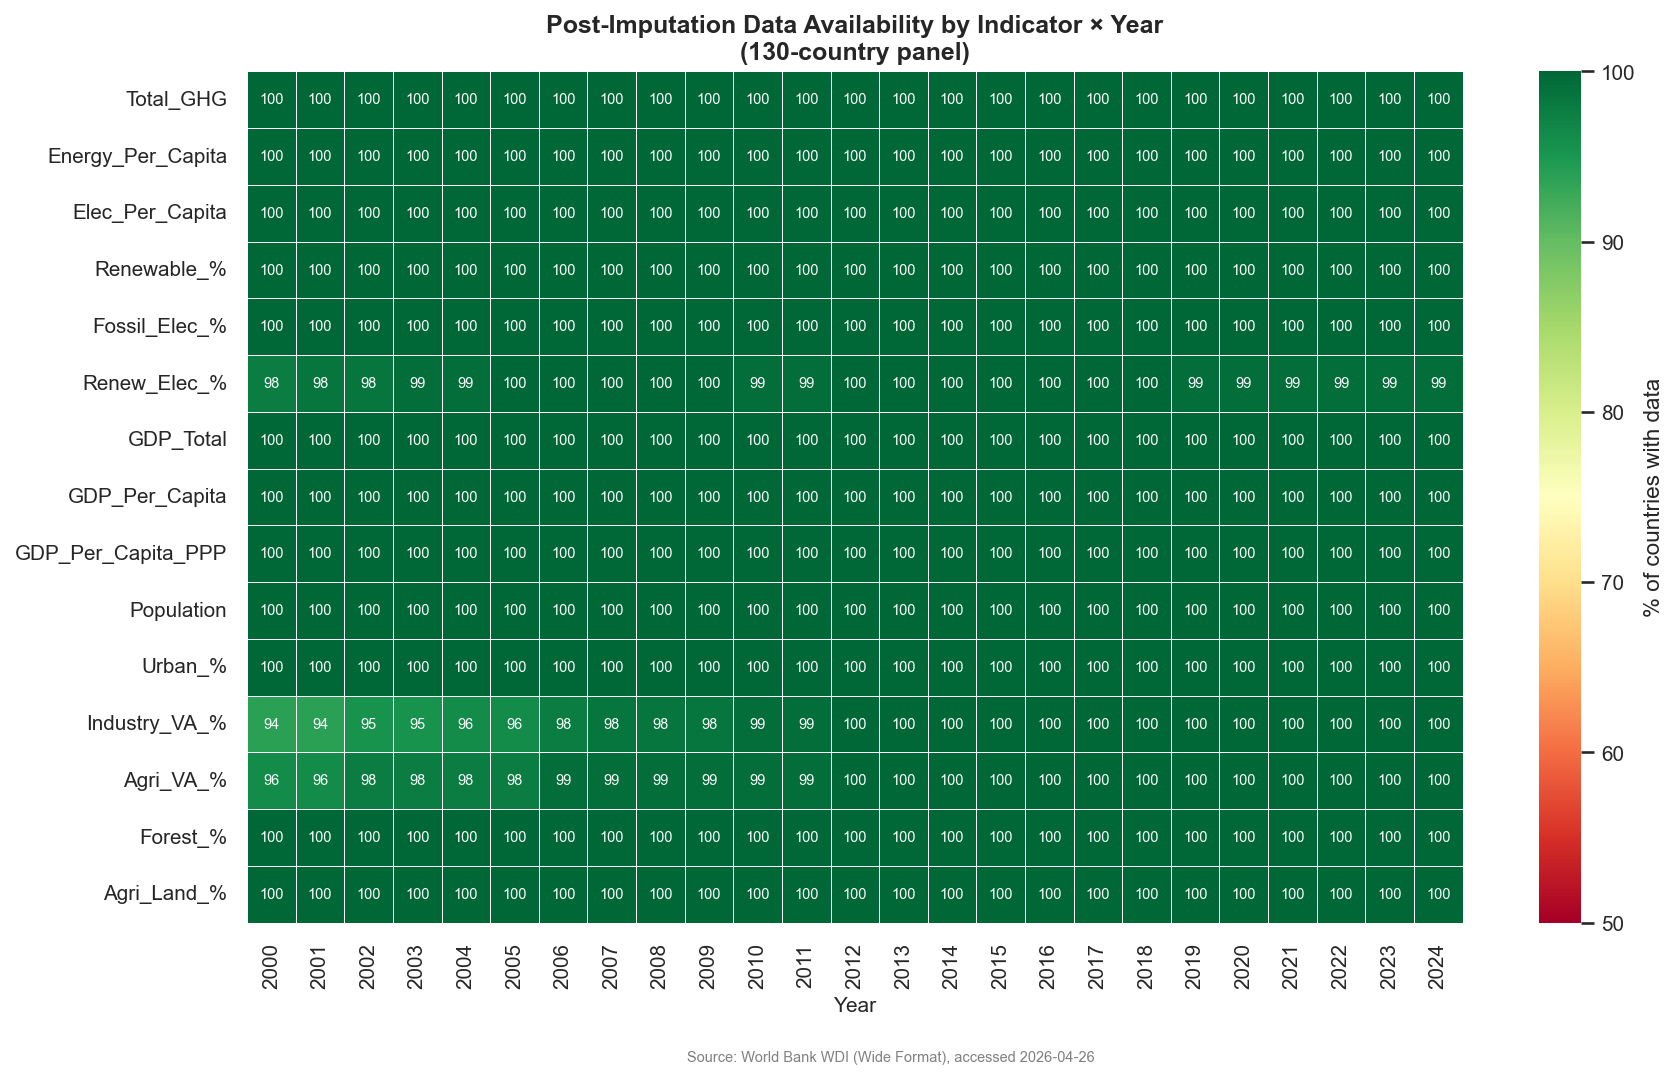

In [161]:
# Missingness heatmap: % of countries with data, by indicator × year
Miss_Matrix = pd.DataFrame(index=Int_Years, columns=All_Cols, dtype=float)
for col in All_Cols:
    if col not in Panel_Df.columns:
        continue
    for yr in Int_Years:
        subset = Panel_Df[Panel_Df.year == yr][col]
        Miss_Matrix.loc[yr, col] = subset.notna().mean() * 100
Miss_Matrix = Miss_Matrix.astype(float)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(Miss_Matrix.T, cmap='RdYlGn', vmin=50, vmax=100,
            annot=True, fmt='.0f', annot_kws={'size': 7}, linewidths=0.3,
            cbar_kws={'label': '% of countries with data'}, ax=ax)
ax.set_title(f'Post-Imputation Data Availability by Indicator × Year\n'
             f'({len(Panel)}-country panel)', fontsize=12, fontweight='bold')
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('')
plt.figtext(0.5, -0.02, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
plt.show()

In [162]:
# Delete use once df/list
del All_Codes, Frames
del Miss_Matrix

## Step 4: Screening & Indicator Selection

We start with the full predictor pool from Step 2 and narrow it down to the final set using data-driven screens. 

The correlation analysis below serves two purposes: 
1. It reveals which indicators are most informative. 
2. It provides the cutoff criteria for selection. 

### Step 4(A) Correlation Heatmaps (Full Predictor Pool)

Two correlation heatmaps across all predictor pool indicators:

- **Pooled correlation**
<br> Standard Pearson r across all country-years. This captures both *level differences between countries* (e.g. large countries emit more) and *changes over time within countries*. It can be misleading because a predictor might look strongly correlated with GHG simply because big countries score high on both.

- **Within-country correlation** 
<br> Pearson r after subtracting each country's time-series mean. This removes the "big vs small country" effect and isolates the question: *when this indicator goes up within a country, does GHG also go up?* This is the correlation that matters for our fixed-effects model, which estimates within-country relationships.

In [163]:
# Log-transform level variables, then compute correlations
Corr_Codes = [Target] + Predictor_Pool.indicator_code.tolist()
Corr_Codes = [c for c in Corr_Codes if c in Short and Short[c] in Panel_Df.columns]

Corr_Df = Panel_Df[['Ref_Area', 'year'] + [Short[c] for c in Corr_Codes]].copy()
for c in Corr_Codes:
    sn = Short[c]
    if c in Log_Vars and sn in Corr_Df.columns:
        Corr_Df[sn] = np.log(Corr_Df[sn].clip(lower=1e-9))

Numeric_Cols = [Short[c] for c in Corr_Codes if Short[c] in Corr_Df.columns]

# Pooled Pearson (all country-years stacked)
Corr_Pooled = Corr_Df[Numeric_Cols].corr(method='pearson')

# Within-country Pearson (subtract each country's mean first)
Demeaned    = Corr_Df.groupby('Ref_Area')[Numeric_Cols].transform(lambda x: x - x.mean())
Corr_Within = Demeaned.corr(method='pearson')

# Rank predictors by |within-country r| with target
Top_Within = Corr_Within[Target_Col].drop(Target_Col).abs().sort_values(ascending=False)
print('Top within-country correlators with Total GHG:')
print(Top_Within.round(3).to_string())

Top within-country correlators with Total GHG:
Energy_Per_Capita     0.673
Elec_Per_Capita       0.651
GDP_Total             0.644
Population            0.632
GDP_Per_Capita_PPP    0.593
GDP_Per_Capita        0.575
Renewable_%           0.551
Urban_%               0.438
Agri_VA_%             0.409
Forest_%              0.340
Agri_Land_%           0.246
Fossil_Elec_%         0.233
Renew_Elec_%          0.218
Industry_VA_%         0.140


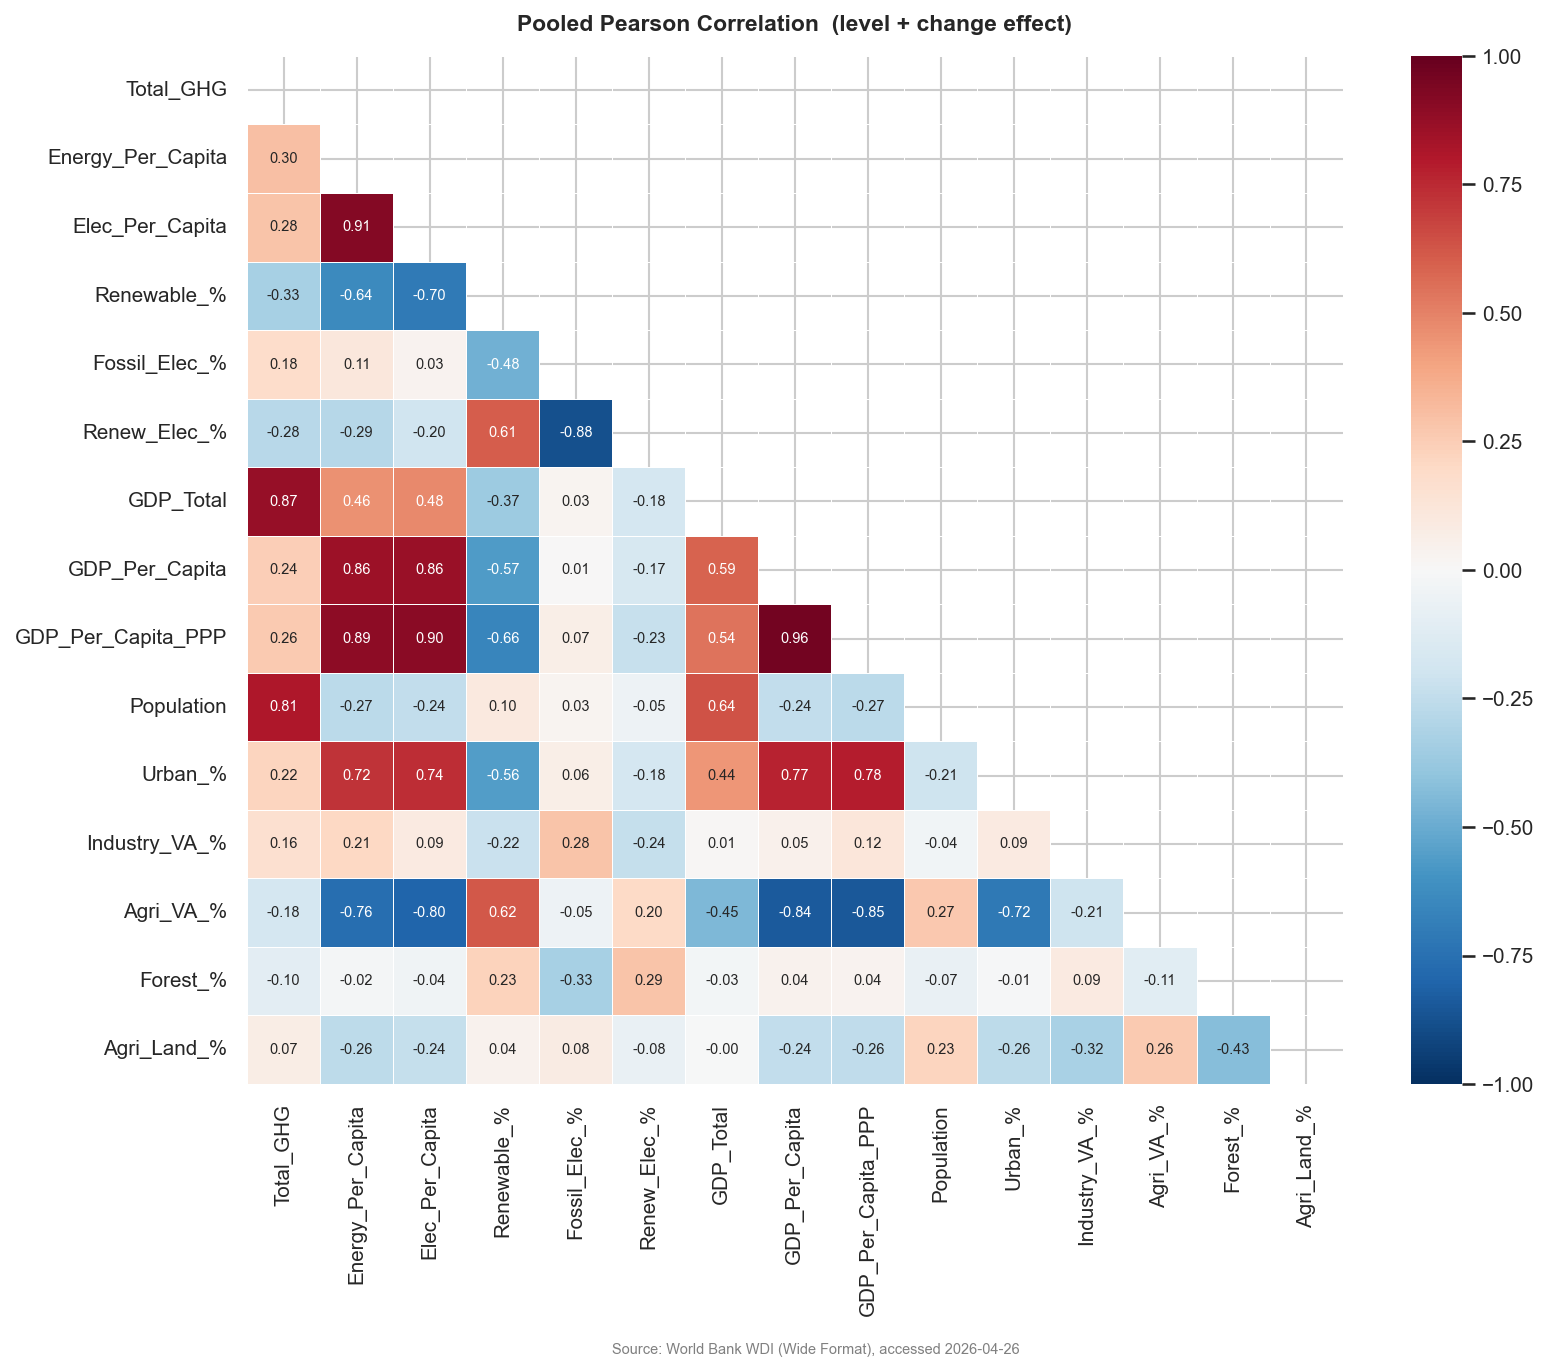

Saved: WS1_Correlation_Pooled.png


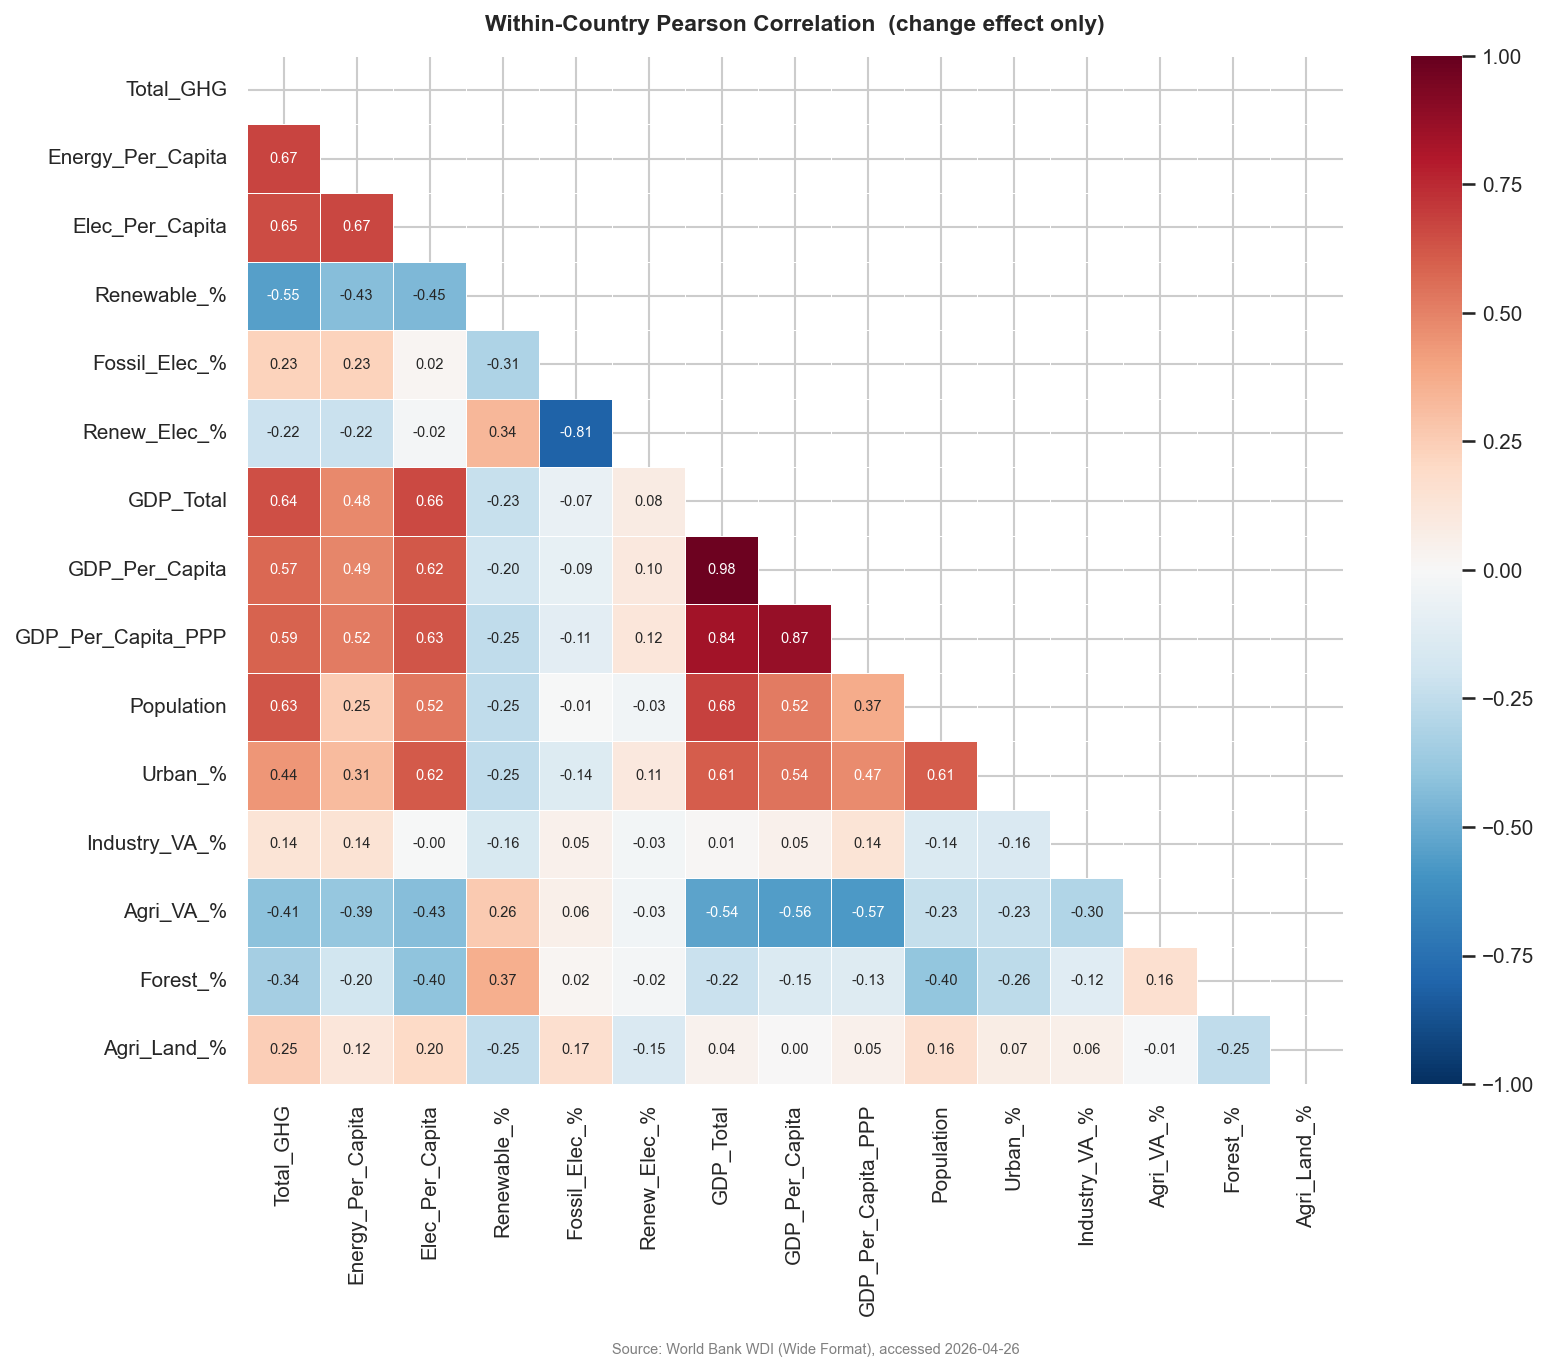

Saved: WS1_Correlation_Within.png


In [164]:
# Plot pooled and within-country correlation heatmaps
Hm_Kwargs = dict(cmap='RdBu_r', vmin=-1, vmax=1, annot=True,
                 fmt='.2f', annot_kws={'size': 7}, linewidths=0.3)

for corr, title, fname in [
    (Corr_Pooled,
     'Pooled Pearson Correlation  (level + change effect)',
     'WS1_Correlation_Pooled.png'),
    (Corr_Within,
     'Within-Country Pearson Correlation  (change effect only)',
     'WS1_Correlation_Within.png'),
]:
    fig, ax = plt.subplots(figsize=(11, 9))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=ax, **Hm_Kwargs)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)
    plt.figtext(0.5, -0.01, WDI_Source, ha='center', fontsize=7, color='grey')
    plt.tight_layout()
    fig.savefig(Output_WS1 / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

### Step 4(B) Screening Bar Chart

Side-by-side bar chart showing how each predictor correlates with GHG, using both pooled and within-country methods.

**How to read this chart:**
- Each row is one predictor.
- The darker bar is the within-country correlation (the one we care about for modelling).
- The lighter bar is the pooled correlation (shown for comparison).
- Predictors with |within-country r| ≥ 0.30 are coloured — these pass the first screen.
- Predictors below the threshold are greyed out — they will be dropped.

Positive correlation: 
 * The predictor moves in the **same** direction as GHG 
 * e.g. more energy use → more emissions 

Negative correlation:
* The predictor moves in the **opposite** direction as GHG 
* e.g. more renewable energy → less emissions 

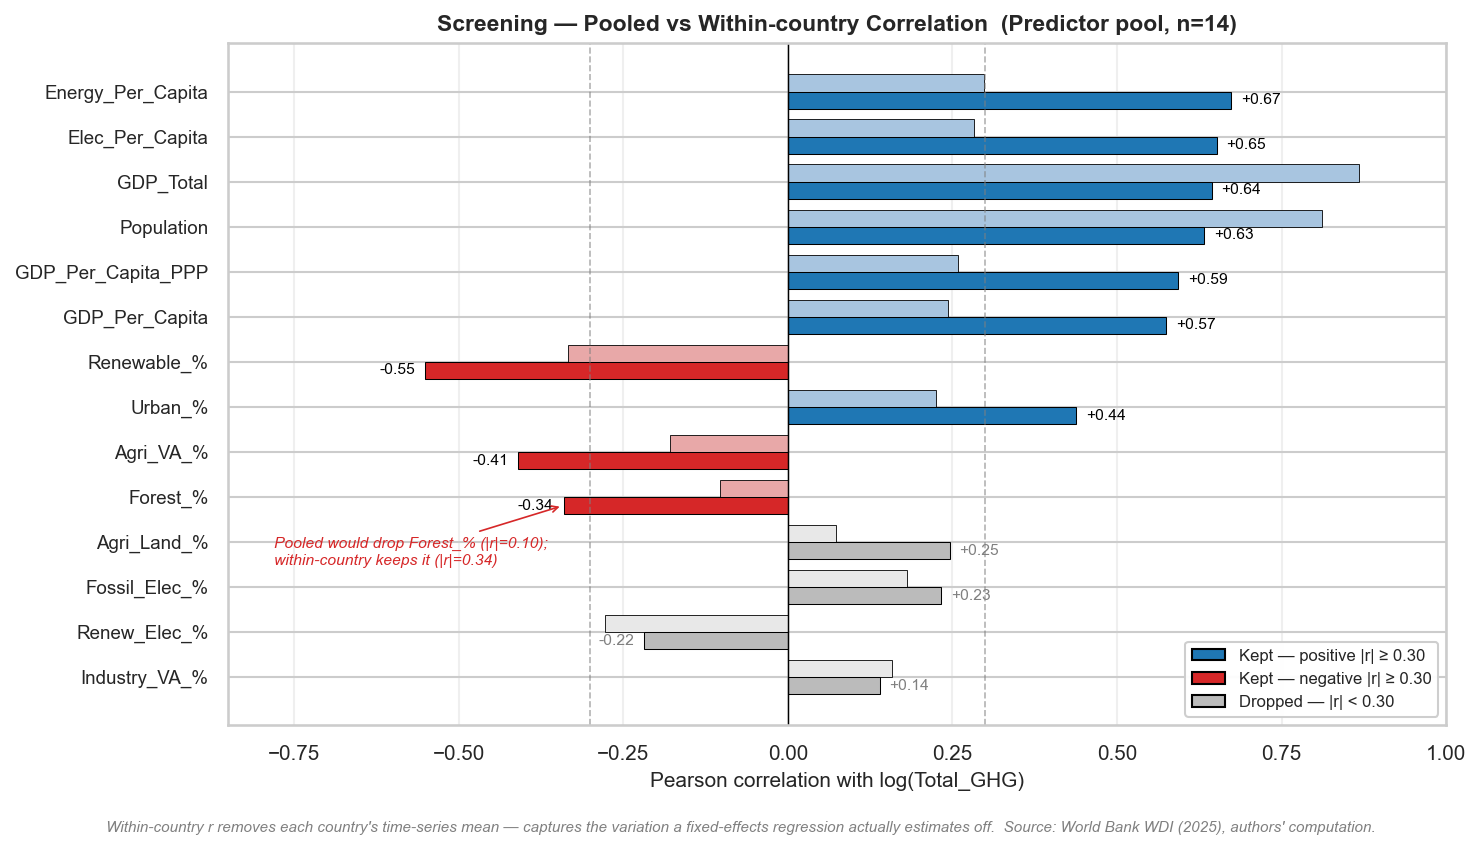


Screen outcome: kept 10 / 14 predictors at |r| ≥ 0.3
  Kept:     Energy_Per_Capita (+0.67), Elec_Per_Capita (+0.65), GDP_Total (+0.64), Population (+0.63), GDP_Per_Capita_PPP (+0.59), GDP_Per_Capita (+0.57), Renewable_% (-0.55), Urban_% (+0.44), Agri_VA_% (-0.41), Forest_% (-0.34)
  Dropped:  Agri_Land_% (+0.25), Fossil_Elec_% (+0.23), Renew_Elec_% (-0.22), Industry_VA_% (+0.14)


In [165]:
# ── Screen 1 bar chart: pooled vs within-country correlation ──────────────────
Screen_Threshold = 0.30

# Extract predictor correlations with target (drop target itself)
Pred_Pooled = Corr_Pooled[Target_Col].drop(Target_Col)
Pred_Within = Corr_Within[Target_Col].drop(Target_Col)

# Sort by |within-country r| descending
Sort_Order    = Pred_Within.abs().sort_values(ascending=False).index.tolist()
Pooled_Values = Pred_Pooled.reindex(Sort_Order).values
Within_Values = Pred_Within.reindex(Sort_Order).values

# Colour coding: kept (|within| ≥ threshold) = colour by sign; dropped = grey
Within_Colours = ['#bbbbbb' if abs(v) < Screen_Threshold else
                  '#1f77b4' if v > 0 else '#d62728'
                  for v in Within_Values]
Pooled_Colours = ['#e8e8e8' if abs(v) < Screen_Threshold else
                  '#a8c5e0' if v > 0 else '#e8a8a8'
                  for v in Within_Values]

# Plot
fig, ax = plt.subplots(figsize=(10, 5.5))
y = np.arange(len(Sort_Order))
h = 0.38

ax.barh(y - h/2, Pooled_Values, h, color=Pooled_Colours,
        edgecolor='black', linewidth=0.4, label='Pooled r (level + change)')
ax.barh(y + h/2, Within_Values, h, color=Within_Colours,
        edgecolor='black', linewidth=0.5, label='Within-country r (change only)')

ax.set_yticks(y)
ax.set_yticklabels(Sort_Order, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.7)
ax.axvline( Screen_Threshold, color='grey', ls='--', lw=0.8, alpha=0.6)
ax.axvline(-Screen_Threshold, color='grey', ls='--', lw=0.8, alpha=0.6)

# Annotate within-country values
for i, v in enumerate(Within_Values):
    ax.text(v + (0.015 if v >= 0 else -0.015), y[i] + h/2,
            f'{v:+.2f}', va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=7.5,
            color='black' if abs(v) >= Screen_Threshold else 'grey')

# Highlight Forest_% if pooled/within disagree on screening
if 'Forest_%' in Sort_Order:
    Fi = Sort_Order.index('Forest_%')
    ax.annotate(
        f'Pooled would drop Forest_% (|r|={abs(Pooled_Values[Fi]):.2f});\n'
        f'within-country keeps it (|r|={abs(Within_Values[Fi]):.2f})',
        xy=(Within_Values[Fi], Fi + h/2),
        xytext=(-0.78, Fi + 1.5),
        fontsize=7.5, color='#d62728', style='italic',
        arrowprops=dict(arrowstyle='->', color='#d62728', lw=0.8))

ax.set_xlabel(f'Pearson correlation with log({Target_Col})', fontsize=10)
ax.set_title(f'Screening — Pooled vs Within-country Correlation  '
             f'(Predictor pool, n={len(Sort_Order)})',
             fontsize=11, fontweight='bold')
ax.set_xlim(-0.85, 1.0)
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#1f77b4', edgecolor='black', label='Kept — positive |r| ≥ 0.30'),
    Patch(facecolor='#d62728', edgecolor='black', label='Kept — negative |r| ≥ 0.30'),
    Patch(facecolor='#bbbbbb', edgecolor='black', label='Dropped — |r| < 0.30'),
], loc='lower right', fontsize=8, framealpha=0.95)

plt.figtext(0.5, -0.02,
            "Within-country r removes each country's time-series mean — "
            "captures the variation a fixed-effects regression actually estimates off.  "
            "Source: World Bank WDI (2025), authors' computation.",
            ha='center', fontsize=7.3, color='grey', style='italic')
plt.tight_layout()
fig.savefig(Output_WS1 / 'WS1_Screening_Chart.png', bbox_inches='tight', dpi=180)
plt.show()

# Summary
Kept = [(lbl, w) for lbl, w in zip(Sort_Order, Within_Values) if abs(w) >= Screen_Threshold]
Drop = [(lbl, w) for lbl, w in zip(Sort_Order, Within_Values) if abs(w) <  Screen_Threshold]
print(f'\nScreen outcome: kept {len(Kept)} / {len(Sort_Order)} predictors at |r| ≥ {Screen_Threshold}')
print('  Kept:    ', ', '.join(f'{l} ({w:+.2f})' for l, w in Kept))
print('  Dropped: ', ', '.join(f'{l} ({w:+.2f})' for l, w in Drop))

### Step 4(C) Three-Screen Indicator Selection

Starting from the predictors that passed the correlation screen above, we apply two more filters:

1. **Screen 1 — Correlation:** 
<br> Already applied above. Drop any predictor with |within-country r| < 0.30.

2. **Screen 2 — Multicollinearity (VIF):**
<br> Drop the highest-VIF predictor until all VIF < 5.0.
<br> A VIF above 5 means that predictor is mostly redundant with others already in the set.

3. **Screen 3 — STIRPAT coverage:** 
<br>  *- STIRPAT-Anchored Indicator Selection -*
<br> 
<br> The STIRPAT framework says national emissions are driven by four factors: 
<br> - Population, Affluence (GDP), Energy intensity, and Carbon intensity of energy. 
<br> We check that at least one predictor represents each factor, so the model has a complete picture.

After screening, **Urban%** is manually added as a predictor for its relevance to insurance exposure analysis in WS3. 
> More urbanisation = more assets in hazard zones

In [166]:
# Collect within-country correlations for all predictor pool indicators
Pred_R = {}
for code in Predictor_Pool.indicator_code:
    if code not in Short:
        continue
    sn = Short[code]
    if sn in Corr_Within.columns:
        Pred_R[sn] = Corr_Within[Target_Col].get(sn, 0.0)

print(f'Predictors entering screening: {len(Pred_R)}')

# Screen 1: drop |within-country r| < 0.30
Candidates_List = list(Pred_R.keys())
Dropped_S1  = [sn for sn in Candidates_List if abs(Pred_R[sn]) < 0.30]
Candidates_List = [sn for sn in Candidates_List if sn not in Dropped_S1]
print(f'\nScreen 1 — |r| ≥ 0.30:  {len(Pred_R)} → {len(Candidates_List)}')
print(f'  Dropped: {Dropped_S1}')

# Screen 2: iteratively remove highest-VIF until all VIF < 5.0
Vif_Threshold = 5.0
print(f'\nScreen 2 — iterative VIF removal (threshold = {Vif_Threshold}):')
iteration = 0
while len(Candidates_List) >= 2:
    vifs = compute_vif(Demeaned[Candidates_List].dropna())
    if vifs.iloc[0] < Vif_Threshold:
        print(f'  All VIFs < {Vif_Threshold}. Stopping.')
        break
    drop = vifs.index[0]
    Candidates_List.remove(drop)
    iteration += 1
    print(f'  Iteration {iteration}: dropped "{drop}" (VIF = {vifs.iloc[0]:.1f})')

print(f'  Survivors: {len(Candidates_List)}')
print('\nFinal VIFs:')
print(compute_vif(Demeaned[Candidates_List].dropna()).round(2).to_string())

# Screen 3: verify STIRPAT factor coverage (P, A, T1, T2)
Groups = {}
for sn in Candidates_List:
    code   = Short_To_Code.get(sn)
    factor = Factor_Lookup.get(code, 'non_stirpat')
    Groups.setdefault(factor, []).append(sn)

print('\nSTIRPAT factor coverage:')
for factor in ['population', 'affluence', 'technology_energy', 'technology_carbon']:
    members = Groups.get(factor, [])
    print(f'  {factor:20s}: {members if members else ">>> MISSING <<<"}')
print(f'  {"non_stirpat":20s}: {Groups.get("non_stirpat", [])}')

# Keep best per STIRPAT factor, then fill with non-STIRPAT up to 10
Final_Predictors = []
for factor in ['population', 'affluence', 'technology_energy', 'technology_carbon']:
    members = Groups.get(factor, [])
    if members:
        best = max(members, key=lambda sn: abs(Pred_R[sn]))
        Final_Predictors.append(best)
        if len(members) > 1:
            print(f'  [{factor}] kept "{best}" over {[m for m in members if m != best]}')

Non_Stirpat = sorted(Groups.get('non_stirpat', []),
                      key=lambda sn: abs(Pred_R[sn]), reverse=True)
Final_Predictors.extend(Non_Stirpat[:10 - len(Final_Predictors)])

#### Manually add Urban% for WS3 insurance exposure
Urban_Short = Short.get(Urban_Code, 'Urban_%')
if Urban_Short not in Final_Predictors:
    Final_Predictors.append(Urban_Short)
    Factor_Lookup[Urban_Code] = 'non_stirpat'
    print(f'\nAdded "{Urban_Short}" as manual predictor (WS3 exposure)')

print(f'\nFinal predictor set ({len(Final_Predictors)}): {Final_Predictors}')

Predictors entering screening: 14

Screen 1 — |r| ≥ 0.30:  14 → 10
  Dropped: ['Fossil_Elec_%', 'Renew_Elec_%', 'Industry_VA_%', 'Agri_Land_%']

Screen 2 — iterative VIF removal (threshold = 5.0):
  Iteration 1: dropped "GDP_Total" (VIF = 23518.8)
  Iteration 2: dropped "GDP_Per_Capita" (VIF = 5.6)
  All VIFs < 5.0. Stopping.
  Survivors: 8

Final VIFs:
Elec_Per_Capita       3.52
GDP_Per_Capita_PPP    2.27
Energy_Per_Capita     2.06
Urban_%               2.02
Population            1.78
Agri_VA_%             1.56
Forest_%              1.39
Renewable_%           1.36

STIRPAT factor coverage:
  population          : ['Population']
  affluence           : ['GDP_Per_Capita_PPP']
  technology_energy   : ['Energy_Per_Capita', 'Elec_Per_Capita']
  technology_carbon   : ['Renewable_%']
  non_stirpat         : ['Urban_%', 'Agri_VA_%', 'Forest_%']
  [technology_energy] kept "Energy_Per_Capita" over ['Elec_Per_Capita']

Final predictor set (7): ['Population', 'GDP_Per_Capita_PPP', 'Energy_Per_Cap

### Step 4(D) Kaya / STIRPAT Validation

Before moving to the full model in WS2, we run a quick check: 
> Do the four core STIRPAT factors (Population, Affluence, Energy, Carbon intensity) actually explain GHG variation when used together?

This cell runs a simple fixed-effects regression with just these four variables. 
<br> If the R² is reasonable, it confirms the STIRPAT framework is a valid foundation for our model.

**Scatter plots:** Each chart shows one STIRPAT factor vs log(Total GHG). Each dot is one country in one year. The line shows the overall trend. The within-country r value tells us how strongly this factor relates to GHG changes *within* each country over time.

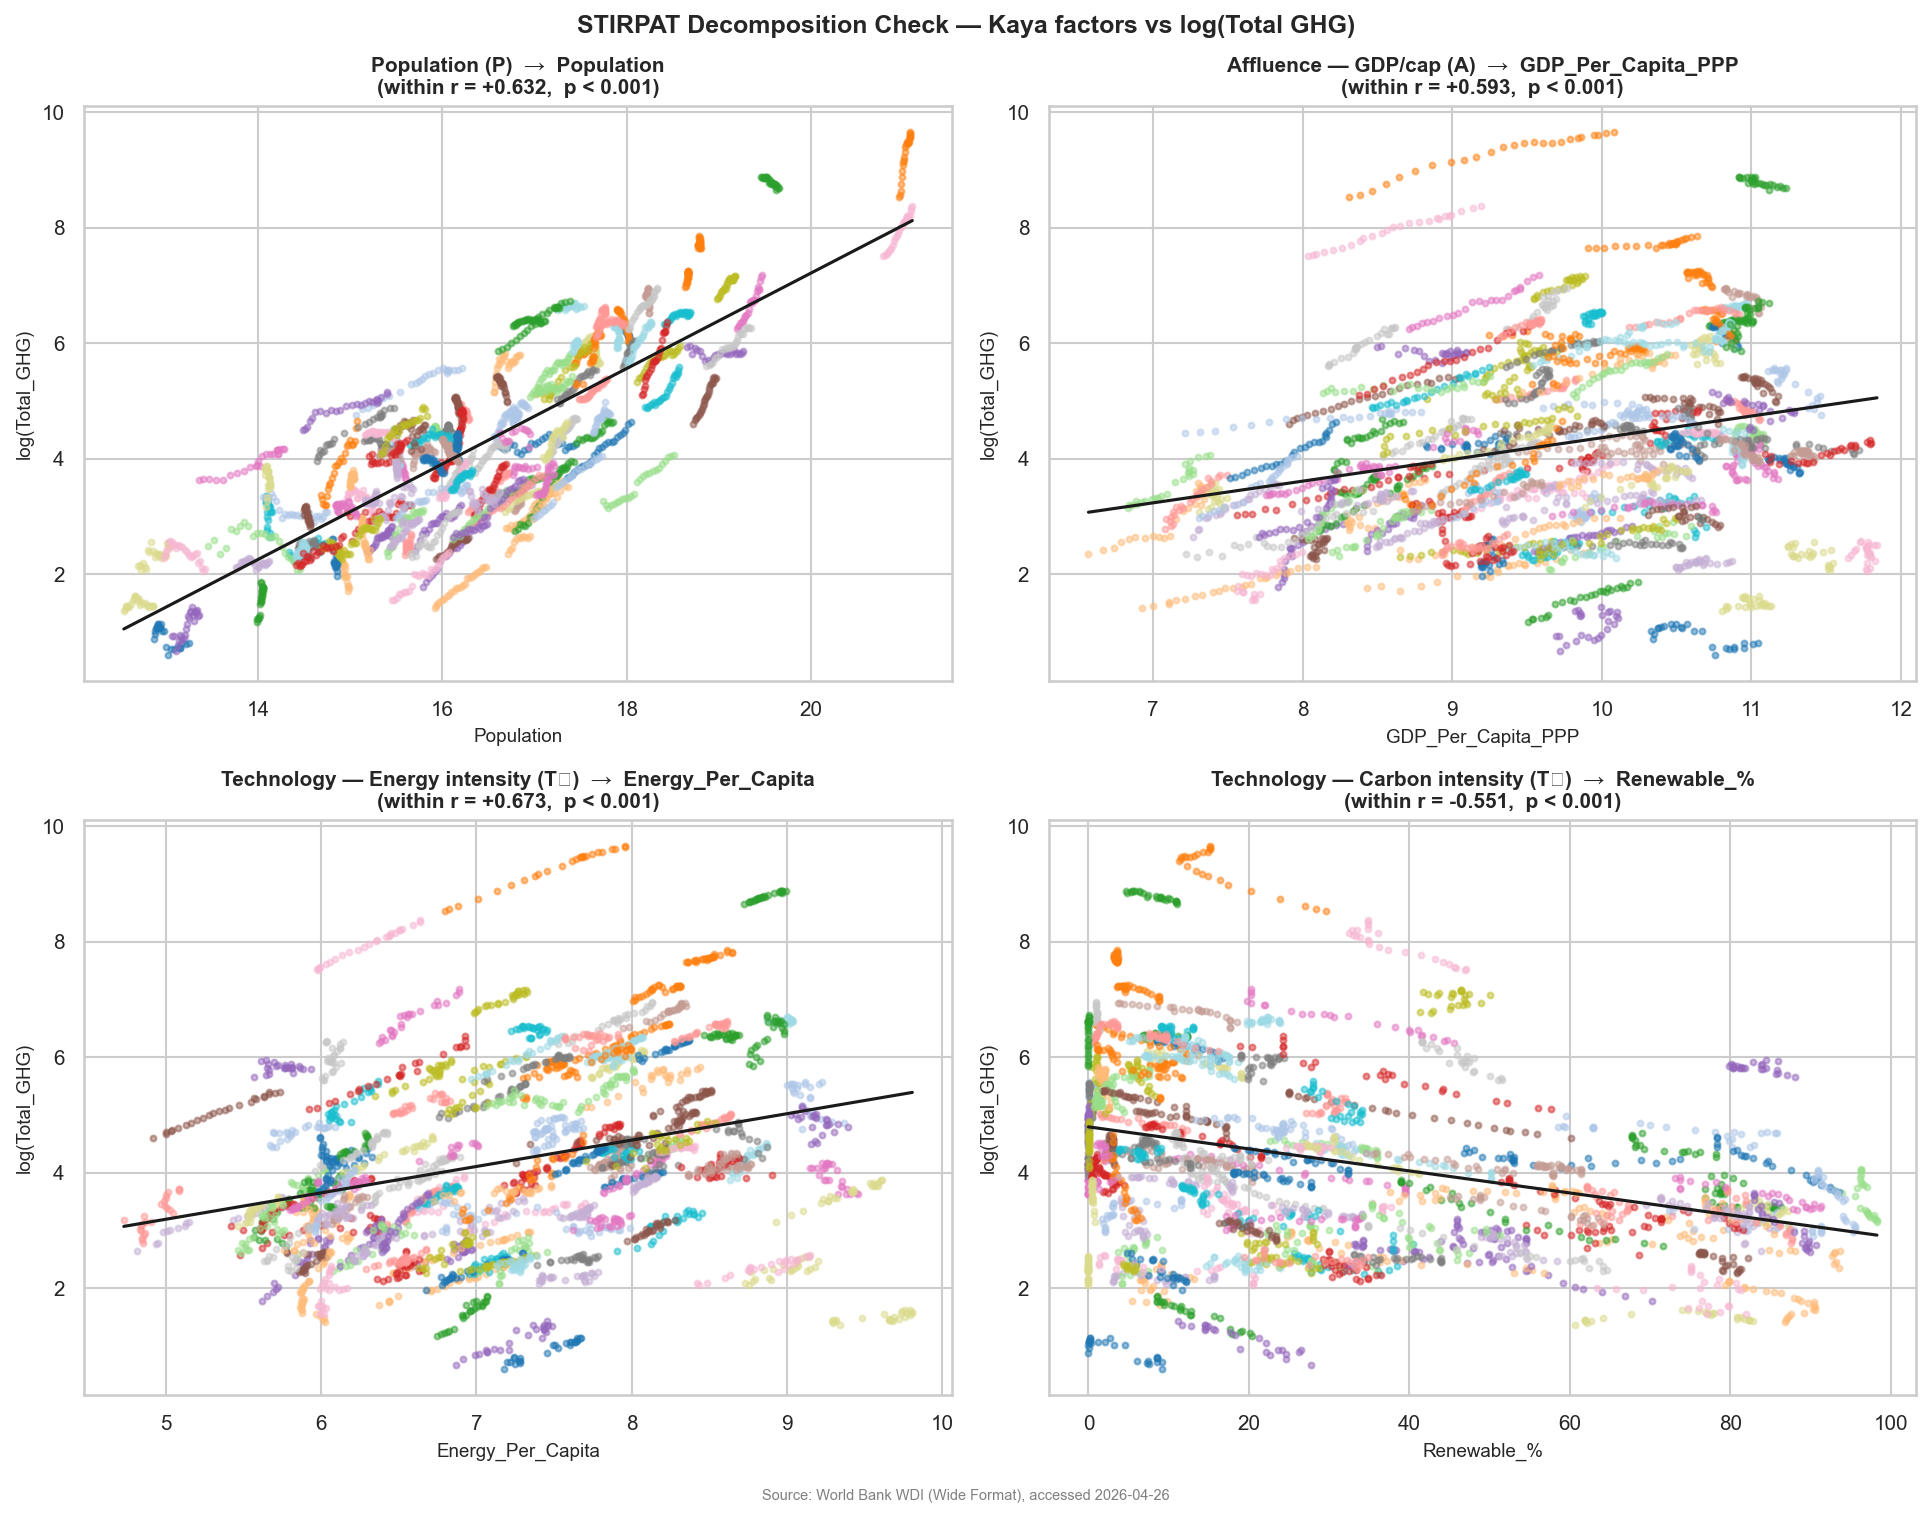

Saved: WS1_Kaya_Check.png

KAYA FACTOR STATISTICS (within-country)
                            Factor              Proxy  Within r p-value
                    Population (P)         Population     0.632 < 0.001
           Affluence — GDP/cap (A) GDP_Per_Capita_PPP     0.593 < 0.001
Technology — Energy intensity (T₁)  Energy_Per_Capita     0.673 < 0.001
Technology — Carbon intensity (T₂)        Renewable_%    -0.551 < 0.001


In [167]:
# Pick one representative per STIRPAT factor 
Kaya_Panels = []
for f in ['population', 'affluence', 'technology_energy', 'technology_carbon']:
    reps = [sn for sn in Final_Predictors
            if Factor_Lookup.get(Short_To_Code.get(sn), '') == f]
    if reps:
        Kaya_Panels.append((f, reps[0]))
    else:
        any_match = [sn for sn in Pred_R
                     if Factor_Lookup.get(Short_To_Code.get(sn), '') == f]
        if any_match:
            Kaya_Panels.append((f, max(any_match, key=lambda sn: abs(Pred_R[sn]))))

Factor_Label = {
    'population':        'Population (P)',
    'affluence':         'Affluence — GDP/cap (A)',
    'technology_energy': 'Technology — Energy intensity (T₁)',
    'technology_carbon': 'Technology — Carbon intensity (T₂)',
}

# Scatter plots with within-country r and p-value 
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
Kaya_Stats = []

# One colour per country for scatter points
Palette     = sns.color_palette('tab20', n_colors=len(Panel))
Country_Pal = dict(zip(sorted(Panel), Palette))

for i, (factor, sn) in enumerate(Kaya_Panels[:4]):
    ax    = axes.flatten()[i]
    sub   = Corr_Df[['Ref_Area', sn, Target_Col]].dropna()
    valid = Demeaned[[sn, Target_Col]].dropna()
    r, p  = stats.pearsonr(valid[sn], valid[Target_Col]) if len(valid) >= 3 else (np.nan, np.nan)

    for country, grp in sub.groupby('Ref_Area'):
        ax.scatter(grp[sn], grp[Target_Col],
                   color=Country_Pal.get(country, 'grey'), s=8, alpha=0.5)

    x, y = sub[sn].values, sub[Target_Col].values
    sl, ic, *_ = stats.linregress(x, y)
    xl = np.linspace(x.min(), x.max(), 100)
    ax.plot(xl, sl * xl + ic, 'k-', lw=1.5)

    p_str = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
    ax.set_title(f'{Factor_Label[factor]}  →  {sn}\n(within r = {r:+.3f},  {p_str})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(sn, fontsize=9)
    ax.set_ylabel(f'log({Target_Col})', fontsize=9)
    Kaya_Stats.append({'Factor': Factor_Label[factor], 'Proxy': sn,
                       'Within r': round(r, 3), 'p-value': p})

fig.suptitle('STIRPAT Decomposition Check — Kaya factors vs log(Total GHG)',
             fontsize=12, fontweight='bold')
plt.figtext(0.5, -0.01, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
fig.savefig(Output_WS1 / 'WS1_Kaya_Check.png', bbox_inches='tight')
plt.show()
print('Saved: WS1_Kaya_Check.png')

# Print stats table 
Kstats_Df = pd.DataFrame(Kaya_Stats)
Kstats_Df['p-value'] = Kstats_Df['p-value'].apply(
    lambda p: '< 0.001' if p < 0.001 else f'{p:.4f}')
print('\n' + '=' * 72)
print('KAYA FACTOR STATISTICS (within-country)')
print('=' * 72)
print(Kstats_Df.to_string(index=False))

In [168]:
# ── Joint fixed-effects regression: 4 Kaya proxies → log(Total GHG) ──────────
Kaya_X_Names = [sn for _, sn in Kaya_Panels[:4]]
Kaya_Xy      = Demeaned[Kaya_X_Names + [Target_Col]].dropna()
X            = Kaya_Xy[Kaya_X_Names].values
y            = Kaya_Xy[Target_Col].values

# OLS on demeaned data = within-country (fixed-effects) regression
X_Const      = np.column_stack([np.ones(len(y)), X])
Coef, *_     = np.linalg.lstsq(X_Const, y, rcond=None)
Y_Hat        = X_Const @ Coef
Ss_Res       = np.sum((y - Y_Hat) ** 2)
Ss_Tot       = np.sum((y - y.mean()) ** 2)
R2_Within    = 1 - Ss_Res / Ss_Tot

n, k         = len(y), len(Kaya_X_Names)
R2_Adj       = 1 - (1 - R2_Within) * (n - 1) / (n - k - 1)
F_Stat       = (R2_Within / k) / ((1 - R2_Within) / (n - k - 1))
F_P          = 1 - stats.f.cdf(F_Stat, k, n - k - 1)

print('=' * 72)
print('JOINT FIXED-EFFECTS REGRESSION — 4 KAYA PROXIES → log(Total GHG)')
print('=' * 72)
print(f'  Observations:  {n}')
print(f'  Predictors:    {Kaya_X_Names}')
print(f'  Within-R²:     {R2_Within:.4f}')
print(f'  Adjusted R²:   {R2_Adj:.4f}')
print(f'  F-statistic:   {F_Stat:.1f}  (p {"< 0.001" if F_P < 0.001 else f"= {F_P:.4f}"})')

# Per-predictor coefficients
Mse      = Ss_Res / (n - k - 1)
Var_Coef = Mse * np.linalg.inv(X_Const.T @ X_Const).diagonal()
SE_Coef  = np.sqrt(Var_Coef)
T_Stats  = Coef / SE_Coef

print(f'\n  {"Predictor":20s}  {"Coef":>8s}  {"SE":>8s}  {"t-stat":>8s}  {"p-value":>10s}')
print(f'  {"-"*20}  {"-"*8}  {"-"*8}  {"-"*8}  {"-"*10}')
for j, name in enumerate(['(intercept)'] + Kaya_X_Names):
    t   = T_Stats[j]
    p_v = 2 * (1 - stats.t.cdf(abs(t), n - k - 1))
    print(f'  {name:20s}  {Coef[j]:8.4f}  {SE_Coef[j]:8.4f}  {t:8.2f}  '
          f'{"< 0.001" if p_v < 0.001 else f"{p_v:.4f}":>10s}')

print(f'\n  The four STIRPAT/Kaya proxies jointly explain {R2_Within*100:.1f}% of within-country GHG variation.')

JOINT FIXED-EFFECTS REGRESSION — 4 KAYA PROXIES → log(Total GHG)
  Observations:  3250
  Predictors:    ['Population', 'GDP_Per_Capita_PPP', 'Energy_Per_Capita', 'Renewable_%']
  Within-R²:     0.7505
  Adjusted R²:   0.7502
  F-statistic:   2440.3  (p < 0.001)

  Predictor                 Coef        SE    t-stat     p-value
  --------------------  --------  --------  --------  ----------
  (intercept)            -0.0000    0.0017     -0.00      1.0000
  Population              0.6055    0.0143     42.30     < 0.001
  GDP_Per_Capita_PPP      0.1759    0.0099     17.79     < 0.001
  Energy_Per_Capita       0.4693    0.0140     33.45     < 0.001
  Renewable_%            -0.0099    0.0004    -24.57     < 0.001

  The four STIRPAT/Kaya proxies jointly explain 75.1% of within-country GHG variation.


In [169]:
# Delete use once df/list
del Corr_Codes, Numeric_Cols
del Hm_Kwargs
del Pred_Pooled, Pred_Within, Sort_Order, Pooled_Values, Within_Values
del Within_Colours, Pooled_Colours, Kept, Drop, Screen_Threshold
del Predictor_Pool, Groups, Non_Stirpat
del Kaya_Stats, Kstats_Df, Factor_Label
del Kaya_Panels, Kaya_X_Names, Kaya_Xy, X, X_Const, Coef, Y_Hat
del Ss_Res, Ss_Tot, R2_Within, R2_Adj, F_Stat, F_P, Mse, Var_Coef, SE_Coef, T_Stats

## Step 5: Focused EDA on Final Indicators

Now that we have our final 7 predictors, we explore them in detail.

### Step 5(A) Scatter Plots — Final Predictors vs GHG

Each chart shows one predictor (x-axis) against log(Total GHG) (y-axis). Each dot is one country in one year — colours represent different countries.

**How to read these charts:**
- A clear upward or downward trend means the predictor has a strong relationship with GHG.
- The black line is the best-fit line; the grey band is the 95% confidence interval (where we expect the true relationship to fall).
- The within-country r value in each title tells us the strength: closer to +1 or −1 means stronger.

**Again:**
Urban% is included even if it is not among the top 6 by correlation, because it is relevant to WS3's insurance exposure analysis (more urban population = more insured assets in disaster-prone areas).

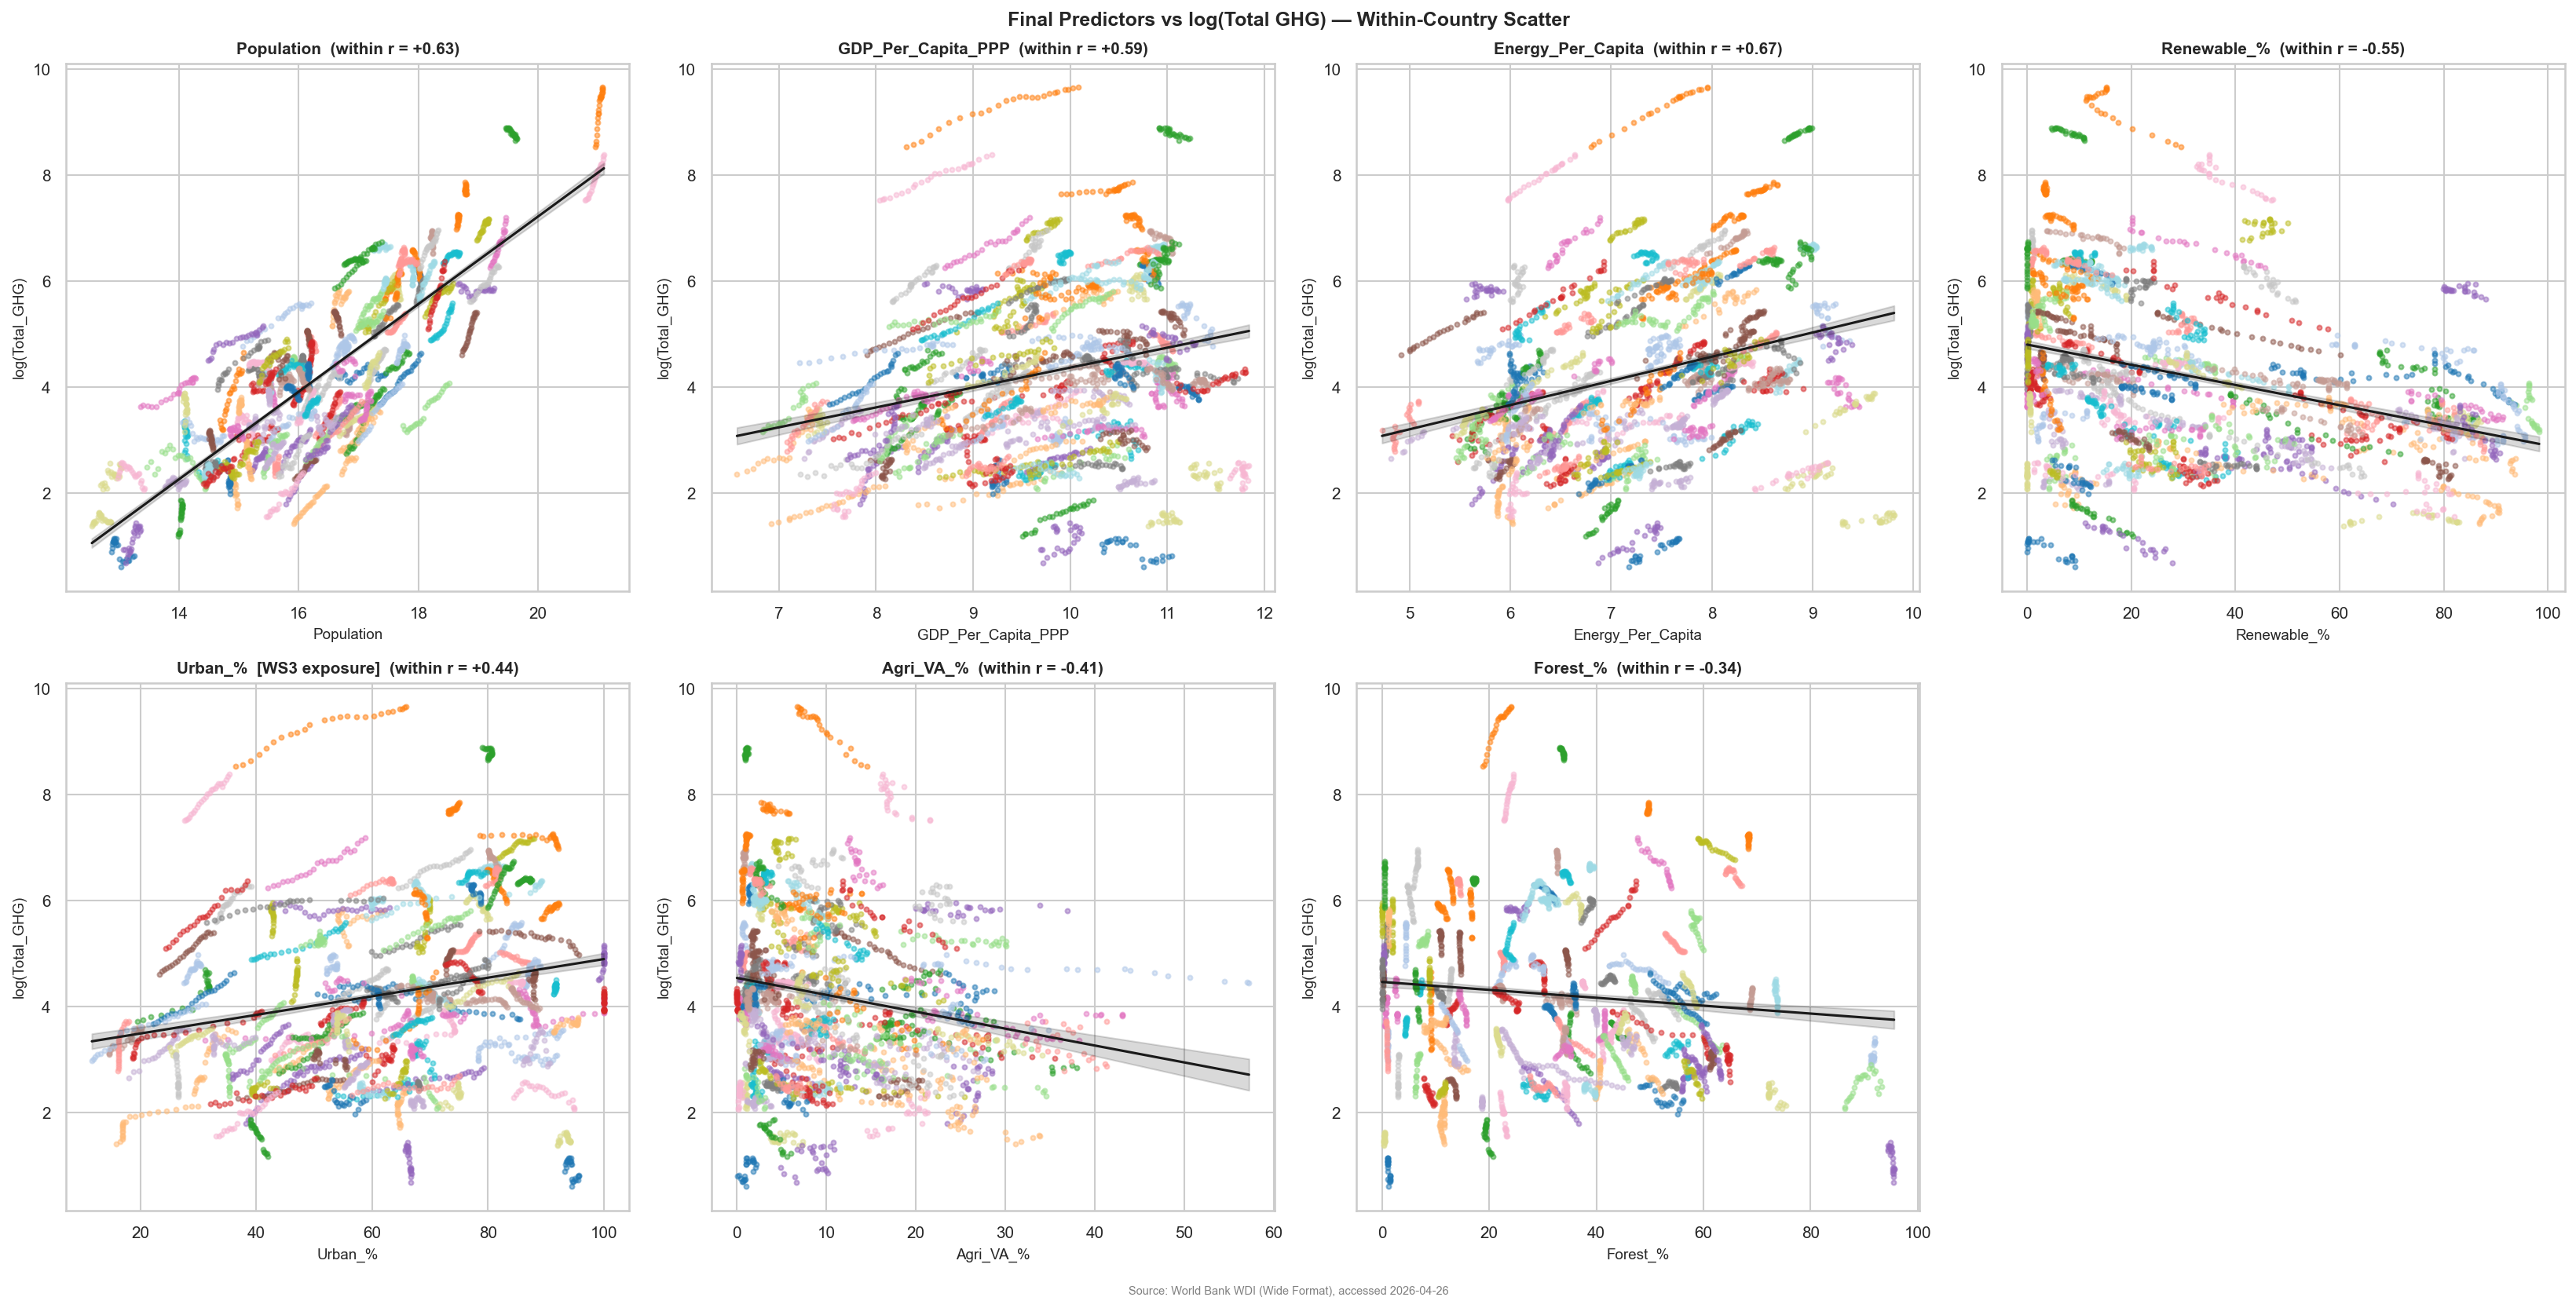

Saved: WS1_Scatter_Final_Predictors.png


In [170]:
# Scatter plots for all final predictors vs log(Total GHG)
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
for i, predictor in enumerate(Final_Predictors):
    ax  = axes.flatten()[i]
    sub = Corr_Df[['Ref_Area', predictor, Target_Col]].dropna()
    r   = Corr_Within[Target_Col].get(predictor, float('nan'))

    for country, grp in sub.groupby('Ref_Area'):
        ax.scatter(grp[predictor], grp[Target_Col],
                   color=Country_Pal.get(country, 'grey'), s=8, alpha=0.5)

    # OLS line + 95% CI
    x, y = sub[predictor].values, sub[Target_Col].values
    sl, ic, *_ = stats.linregress(x, y)
    xl  = np.linspace(x.min(), x.max(), 100)
    yl  = sl * xl + ic
    res = y - (sl * x + ic)
    se  = np.sqrt(res.var() / len(x) +
                  (xl - x.mean())**2 * res.var() / np.sum((x - x.mean())**2))
    ax.plot(xl, yl, 'k-', lw=1.5)
    ax.fill_between(xl, yl - 1.96*se, yl + 1.96*se, alpha=0.15, color='black')

    tag = '  [WS3 exposure]' if predictor == Urban_Short else ''
    ax.set_title(f'{predictor}{tag}  (within r = {r:+.2f})', fontsize=10, fontweight='bold')
    ax.set_xlabel(predictor, fontsize=9)
    ax.set_ylabel(f'log({Target_Col})', fontsize=9)

# Hide unused subplot (8th cell in 2×4 grid)
if len(Final_Predictors) < 8:
    axes.flatten()[7].axis('off')

fig.suptitle(f'Final Predictors vs log(Total GHG) — Within-Country Scatter',
             fontsize=12, fontweight='bold')
plt.figtext(0.5, -0.01, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
fig.savefig(Output_WS1 / 'WS1_Scatter_Final_Predictors.png', bbox_inches='tight')
plt.show()
print('Saved: WS1_Scatter_Final_Predictors.png')

### Step 5(B) Time Trends (2000–2024)

Each chart shows how one indicator changed over the 25-year period across our 135-country panel.

**How to read these charts:**
- The solid line is the **median** — the middle value across all 135 countries each year.
- The shaded band shows the range between the 25th and 75th percentile (the middle 50% of countries). A wider band means countries are more spread out on that indicator.
- Grey shading marks 2020–2021 (COVID-19 years).

We use median instead of mean because a few very large countries (China, USA, India) would dominate the average. Median gives a more representative picture of the "typical" country.

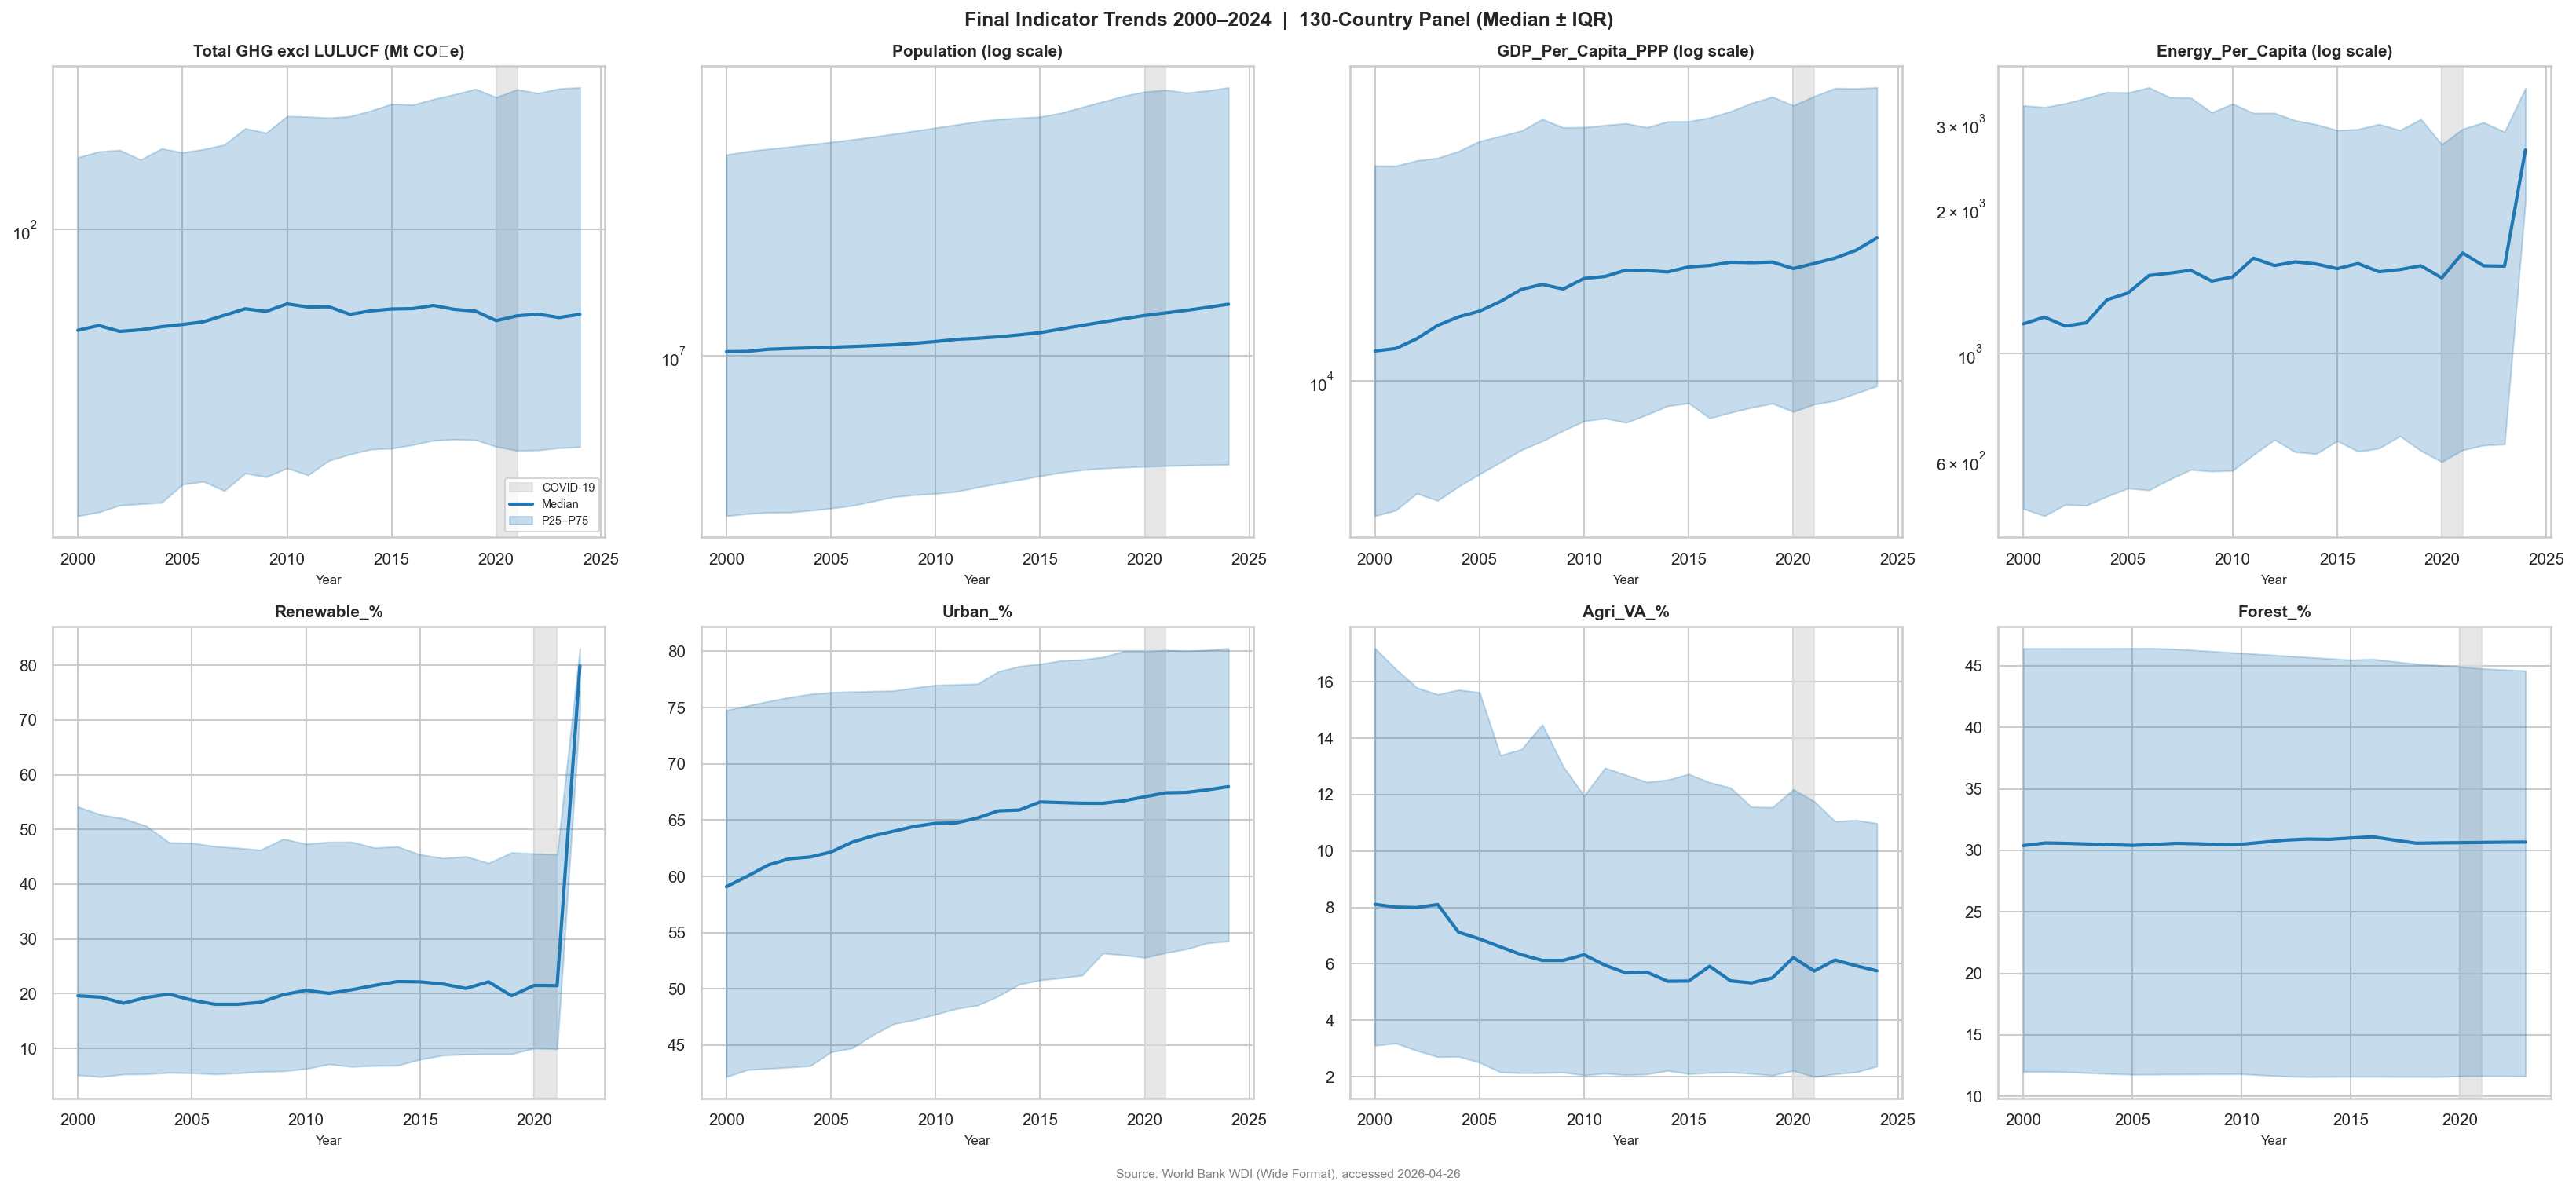

Saved: WS1_Time_Trends.png


In [171]:
# Time trends for target + all final predictors
def trend_entry(short_name):
    code = Short_To_Code[short_name]
    is_log = code in Log_Vars
    label = f'{short_name} (log scale)' if is_log else short_name
    return (code, label, is_log)

Trend_Codes = [(Target, 'Total GHG excl LULUCF (Mt CO₂e)', True)]
for sn in Final_Predictors:
    Trend_Codes.append(trend_entry(sn))

# Calculate grid size needed
n_plots = len(Trend_Codes)
n_cols  = 4
n_rows  = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 5 * n_rows))
for ax_idx, (code, title, use_log) in enumerate(Trend_Codes):
    ax   = axes.flatten()[ax_idx]
    rows = get_rows(WDI_Panel, code)
    ax.axvspan(2020, 2021, color='#dddddd', alpha=0.7,
               label='COVID-19' if ax_idx == 0 else None)

    if rows.empty:
        ax.set_title(f'{title}\n(no data)', fontsize=9, color='grey')
        continue

    pivot       = rows.set_index('Ref_Area')[Years].apply(pd.to_numeric, errors='coerce').reindex(Panel)
    median_vals = pivot.median(axis=0).values.astype(float)
    p25_vals    = pivot.quantile(0.25, axis=0).values.astype(float)
    p75_vals    = pivot.quantile(0.75, axis=0).values.astype(float)

    ax.plot(Int_Years, median_vals, color='#1f77b4', lw=2, label='Median')
    ax.fill_between(Int_Years, p25_vals, p75_vals, alpha=0.25, color='#1f77b4', label='P25–P75')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Year', fontsize=8)
    if use_log:
        ax.set_yscale('log')
    if ax_idx == 0:
        ax.legend(loc='lower right', fontsize=7)

# Hide unused subplots
for ax_idx in range(len(Trend_Codes), n_rows * n_cols):
    axes.flatten()[ax_idx].axis('off')

fig.suptitle(f'Final Indicator Trends 2000–2024  |  {len(Panel)}-Country Panel (Median ± IQR)',
             fontsize=12, fontweight='bold')
plt.figtext(0.5, -0.01, WDI_Source, ha='center', fontsize=7.5, color='grey')
plt.tight_layout()
fig.savefig(Output_WS1 / 'WS1_Time_Trends.png', bbox_inches='tight')
plt.show()
print('Saved: WS1_Time_Trends.png')

**Trend notes:** 
- GHG median rises steadily through 2019, drops sharply in 2020 due to COVID-related economic slowdowns, then rebounds in 2021–2022. 
- The widening shaded band over time suggests increasing spread — countries are becoming more different from each other in their emission levels.

**COVID treatment for WS2:** We add a binary dummy variable (2020=1, 2021=1, else 0). This keeps all data points in the panel while allowing the model to account for the COVID disruption separately.

### Step 5(C) GHG Composition

Stacked area chart showing the breakdown of Total GHG into its components: 
<br> CO₂, methane (CH₄), and nitrous oxide (N₂O), summed across all 135 countries.

This chart is for context only. 
* These components are **not** used as predictors (since they are parts of the target variable, using them would be circular). 
* It helps us understand *what drives* Total GHG: CO₂ from fossil fuels is the largest share, followed by methane (mainly from agriculture and energy production). 

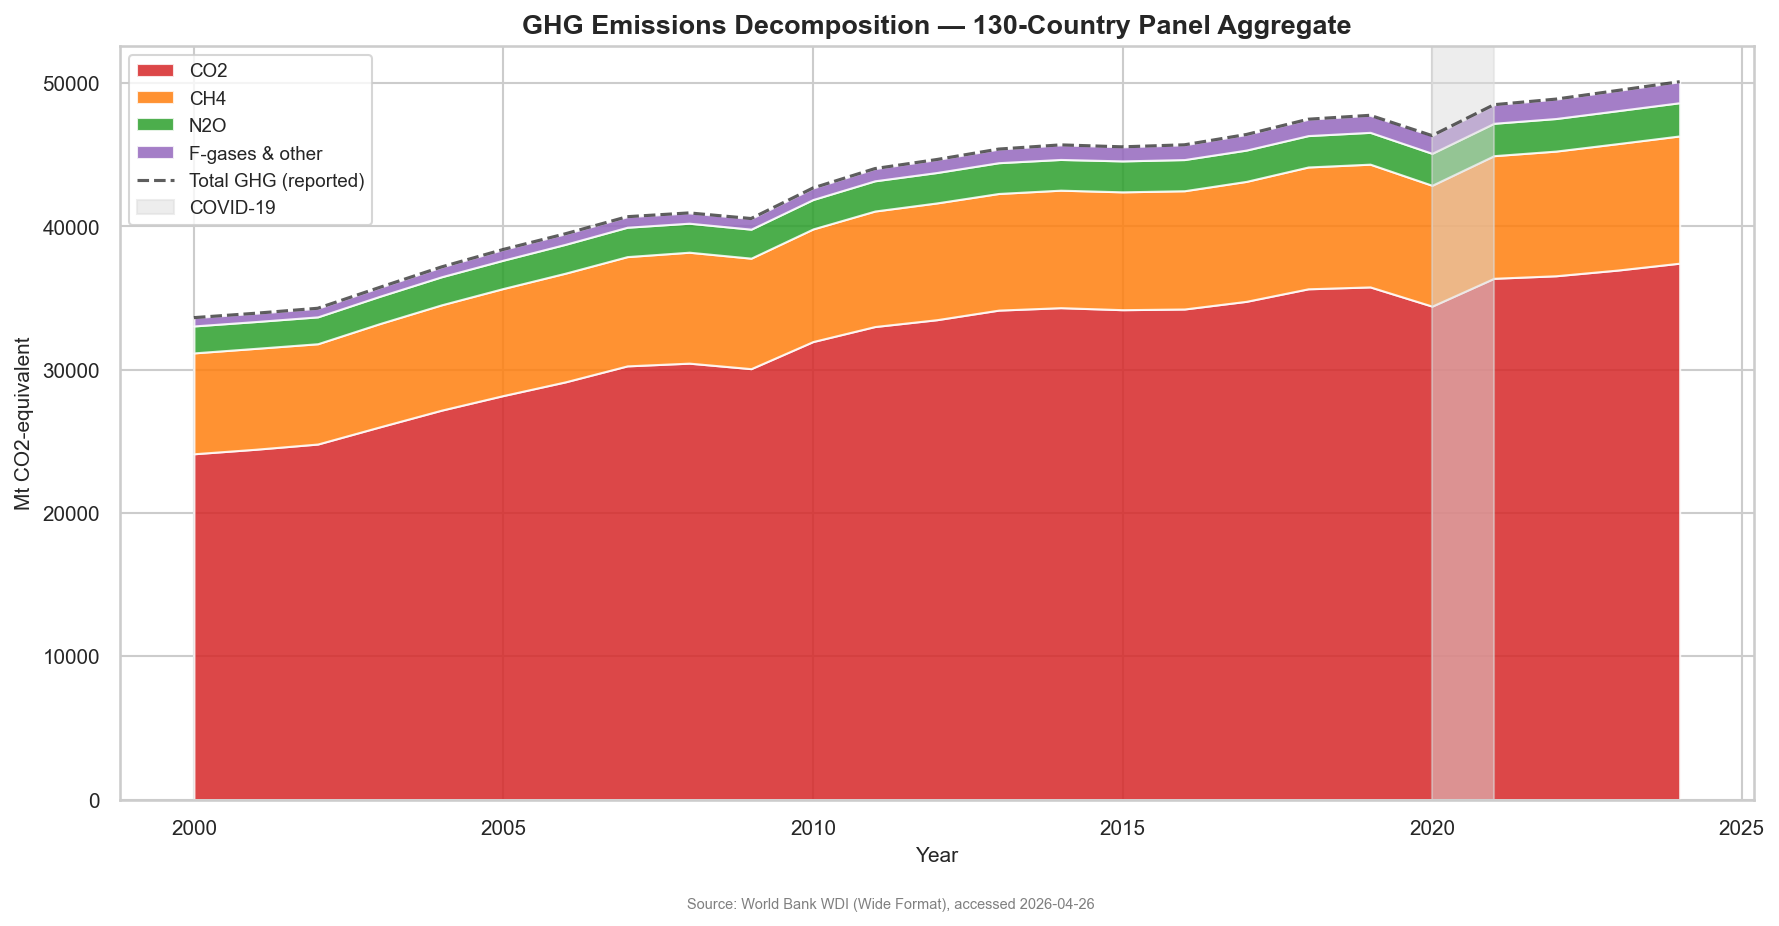

In [172]:
# Load GHG sub-components for decomposition chart (not used as predictors)
Ghg_Components = {
    'WB_WDI_EN_GHG_CO2_MT_CE_AR5': 'CO2',
    'WB_WDI_EN_GHG_CH4_MT_CE_AR5': 'CH4',
    'WB_WDI_EN_GHG_N2O_MT_CE_AR5': 'N2O',
}

Ghg_Frames = []
for code, label in Ghg_Components.items():
    rows = get_rows(WDI_Panel, code)
    if rows.empty:
        print(f'  WARNING: {label} ({code}) not found')
        continue
    melted = (rows[['Ref_Area'] + Years]
              .melt(id_vars='Ref_Area', value_vars=Years,
                    var_name='year', value_name=label)
              .assign(year=lambda x: x.year.astype(int))
              .groupby(['Ref_Area', 'year'])[label].mean()
              .reset_index())
    Ghg_Frames.append(melted)

# Also get Total GHG
GHG_Panel = (get_rows(WDI_Panel, Target)[['Ref_Area'] + Years]
             .melt(id_vars='Ref_Area', value_vars=Years,
                   var_name='year', value_name='Total GHG')
             .assign(year=lambda x: x.year.astype(int))
             .groupby(['Ref_Area', 'year'])['Total GHG'].mean()
             .reset_index())

for f in Ghg_Frames:
    GHG_Panel = GHG_Panel.merge(f, on=['Ref_Area', 'year'], how='left')

# Aggregate across all countries
Ghg_Agg = GHG_Panel.groupby('year')[['Total GHG', 'CO2', 'CH4', 'N2O']].sum()
Ghg_Agg['F-gases & other'] = (Ghg_Agg['Total GHG'] - Ghg_Agg[['CO2', 'CH4', 'N2O']].sum(axis=1)).clip(lower=0)

# Stacked area chart
fig, ax = plt.subplots(figsize=(12, 6))
Stack_Cols = [c for c in ['CO2', 'CH4', 'N2O', 'F-gases & other'] if c in Ghg_Agg.columns]
ax.stackplot(Ghg_Agg.index, *[Ghg_Agg[c].values for c in Stack_Cols],
             labels=Stack_Cols, colors=['#d62728', '#ff7f0e', '#2ca02c', '#9467bd'], alpha=0.85)
ax.plot(Ghg_Agg.index, Ghg_Agg['Total GHG'], 'k--', lw=1.5, label='Total GHG (reported)', alpha=0.7)
ax.axvspan(2020, 2021, color='#dddddd', alpha=0.5, label='COVID-19')
ax.set_title(f'GHG Emissions Decomposition — {len(Panel)}-Country Panel Aggregate',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Mt CO2-equivalent', fontsize=10)
ax.legend(loc='upper left', fontsize=9)
plt.figtext(0.5, -0.02, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
plt.show()

### Step 5(D) COVID Disruption Check

Boxplot showing the year-over-year % change in Total GHG for each year from 2018 to 2023. Each box summarises the distribution across all 135 countries.

* A clear dip in 2020 (red box) confirms that the COVID effect on emissions was widespread, not just a few countries. 
* This supports our decision to flag 2020–2021 with a dummy variable rather than treating them as normal data. 

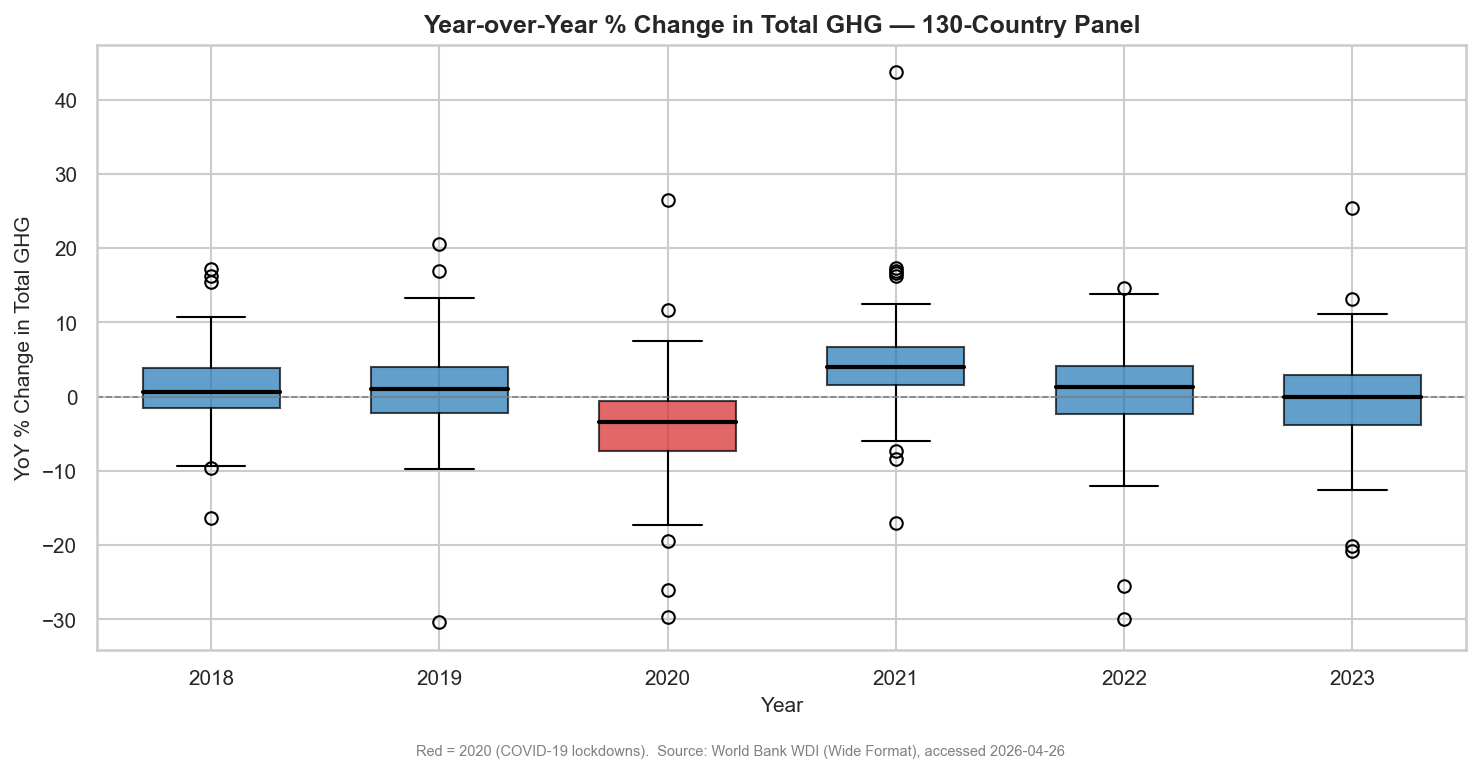


=== COVID Disruption Summary ===
  2018:  median = +0.65%,  mean = +1.12%
  2019:  median = +1.05%,  mean = +1.00%
  2020:  median = -3.47%,  mean = -3.60%
  2021:  median = +3.98%,  mean = +4.16%
  2022:  median = +1.26%,  mean = +0.62%
  2023:  median = -0.00%,  mean = -0.37%

  → COVID dummy empirically supported.


In [173]:
# YoY % change in Total GHG, 2018–2023
Ghg_Wide = GHG_Panel.pivot(index='year', columns='Ref_Area', values='Total GHG')
Yoy_Pct  = (Ghg_Wide.pct_change() * 100).loc[2018:2023].T
Yoy_Melt = (Yoy_Pct.reset_index()
            .melt(id_vars='Ref_Area', var_name='year', value_name='yoy_pct_change')
            .dropna())

# Boxplot: distribution of YoY changes per year
fig, ax = plt.subplots(figsize=(10, 5))
Years_Plot = sorted(Yoy_Melt.year.unique())
Box_Data   = [Yoy_Melt[Yoy_Melt.year == y]['yoy_pct_change'].values for y in Years_Plot]

bp = ax.boxplot(Box_Data, labels=[str(y) for y in Years_Plot], patch_artist=True,
                widths=0.6, medianprops=dict(color='black', lw=2))
for i, y in enumerate(Years_Plot):
    bp['boxes'][i].set_facecolor('#d62728' if y == 2020 else '#1f77b4')
    bp['boxes'][i].set_alpha(0.7)

ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.set_title(f'Year-over-Year % Change in Total GHG — {len(Panel)}-Country Panel',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('YoY % Change in Total GHG', fontsize=10)
plt.figtext(0.5, -0.02, 'Red = 2020 (COVID-19 lockdowns).  ' + WDI_Source,
            ha='center', fontsize=7, color='grey')
plt.tight_layout()
plt.show()

# Median/mean per year
print('\n=== COVID Disruption Summary ===')
for y in Years_Plot:
    vals = Yoy_Melt[Yoy_Melt.year == y]['yoy_pct_change']
    print(f'  {y}:  median = {vals.median():+.2f}%,  mean = {vals.mean():+.2f}%')

Med_2020 = Yoy_Melt[Yoy_Melt.year == 2020]['yoy_pct_change'].median()
print(f'\n  → COVID dummy {"empirically supported" if Med_2020 < -2 else "effect weak — consider if needed"}.')

### Step 5(E) Outlier Scan

Flag any observation where a country's value in a given year is more than 3 standard deviations from that country's own mean (z-score > 3).

> **Decision: keep all flagged observations.** 
* These are not data errors, they represent real events 
<br> - (e.g. post-crisis economic rebounds, sudden policy changes, or natural disaster impacts) 
* Removing them would discard meaningful information.

In [174]:
# Flag |z-score| > 3 within each country — keep all (real events, not errors)
Outlier_Records = []
for col in All_Cols:
    if col not in Panel_Df.columns:
        continue
    z_scores = Panel_Df.groupby('Ref_Area')[col].transform(
        lambda s: (s - s.mean()) / s.std() if s.std() > 0 else 0)
    flagged = Panel_Df[z_scores.abs() > 3][['Ref_Area', 'year']].copy()
    flagged['indicator'] = col
    flagged['value']     = Panel_Df.loc[flagged.index, col].values
    flagged['z_score']   = z_scores.loc[flagged.index].values
    Outlier_Records.append(flagged)

Outliers = pd.concat(Outlier_Records, ignore_index=True) if Outlier_Records else pd.DataFrame()
if Outliers.empty:
    print('No outliers found (|z| > 3 within country).')
else:
    Outliers = Outliers.sort_values(by='z_score', key=abs, ascending=False)
    print(f'=== {len(Outliers)} observations flagged (|z| > 3) — ALL retained ===')
    print(Outliers.to_string(index=False))

=== 32 observations flagged (|z| > 3) — ALL retained ===
Ref_Area  year          indicator       value   z_score
     TKM  2012        Renewable_%    0.000000 -4.800000
     MDG  2000        Agri_Land_%   69.642673 -4.691903
     GTM  2000          Agri_VA_%   22.821148  4.026163
     NPL  2000      Fossil_Elec_%    4.456902  3.994260
     TTO  2000        Agri_Land_%   13.060429  3.729258
     NAM  2008      Fossil_Elec_%   11.216730  3.523040
     ECU  2000          Agri_VA_%   12.401175  3.506043
     MOZ  2000    Elec_Per_Capita  123.168381 -3.460435
     KWT  2000            Urban_%   99.000000 -3.451417
     LBY  2000            Urban_%   86.950851 -3.396017
     NAM  2009       Renew_Elec_%   66.108579 -3.361025
     TKM  2000            Urban_%   46.073669 -3.342945
     ISL  2024        Agri_Land_%   16.245165 -3.296113
     ISL  2023        Agri_Land_%   16.245165 -3.296113
     LTU  2000        Agri_Land_%   54.530951  3.290539
     HND  2000      Industry_VA_%   29.380934  

### Step 5(F) Country Clustering

Group countries into 5 clusters based on their average predictor values (e.g. how much energy they use, how urbanised they are, how much forest they have). Countries with similar profiles end up in the same cluster.

**Why this matters:**
- It shows that countries in our panel have genuinely different emissions driver profiles — which justifies using country fixed effects in our model (each country gets its own baseline).
- It shows where our SE Asian focus countries (Thailand, Philippines, Malaysia, Indonesia, Vietnam) sit relative to global peers. Countries highlighted in red on the chart are the SE Asian ones.

The chart is a dendrogram (tree diagram) — countries that join together at low height are more similar to each other. 

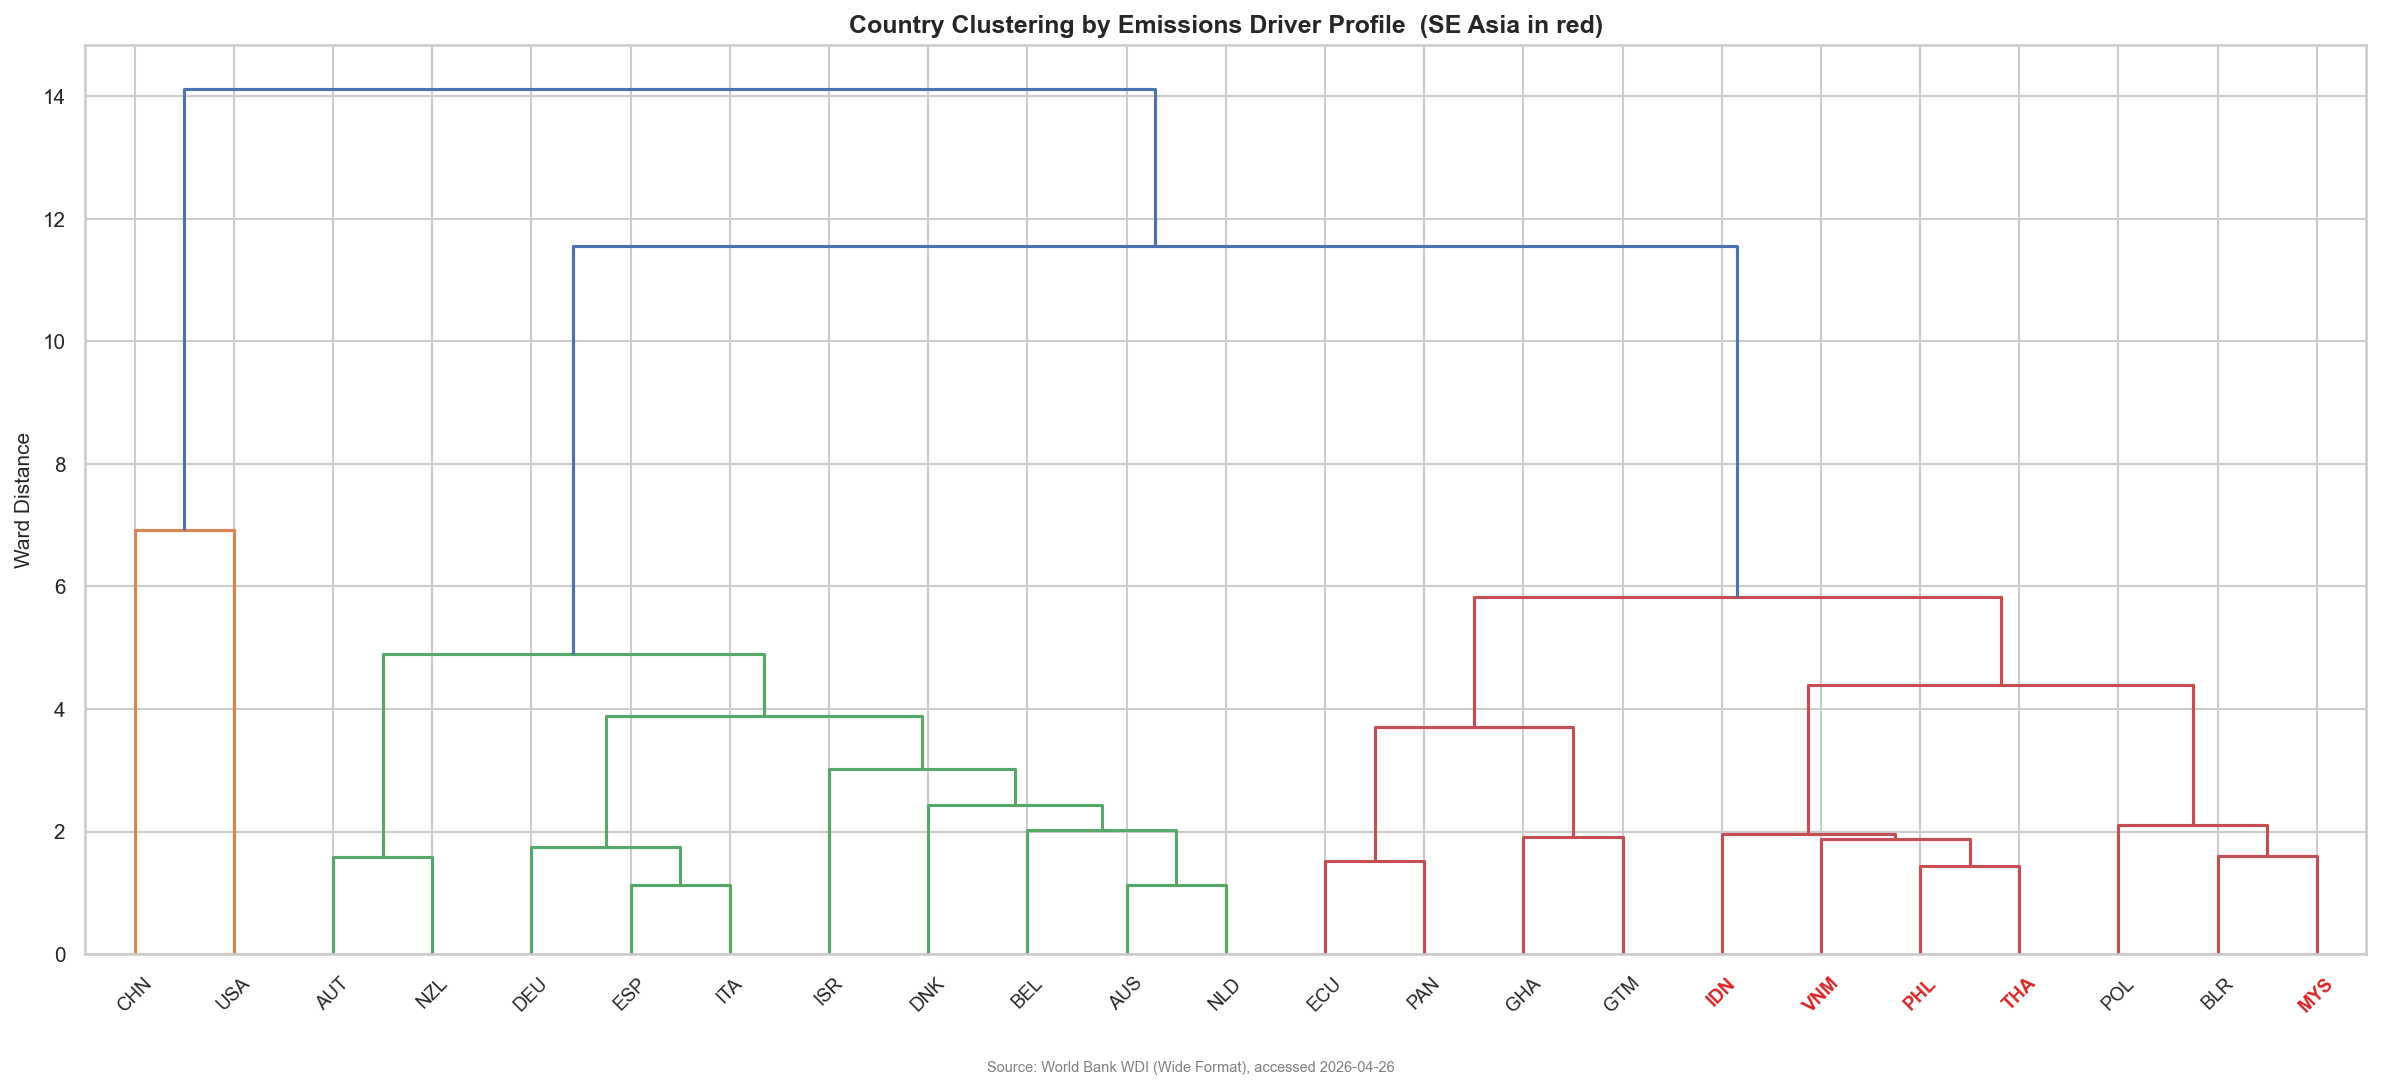


=== 5-Cluster Summary ===
  Cluster 1: 2 countries  |  SE Asia: none
  Cluster 2: 29 countries  |  SE Asia: none
  Cluster 3: 33 countries  |  SE Asia: ['IDN', 'PHL', 'THA', 'VNM']
  Cluster 4: 25 countries  |  SE Asia: none
  Cluster 5: 41 countries  |  SE Asia: ['MYS']


In [175]:
# Hierarchical clustering on standardised country-mean predictor profiles
Country_Profiles = Panel_Df.groupby('Ref_Area')[Pred_Cols].mean().dropna()
if 'Population' in Country_Profiles.columns:
    Country_Profiles['Population'] = np.log(Country_Profiles['Population'].clip(lower=1))

Profiles_Std = (Country_Profiles - Country_Profiles.mean()) / Country_Profiles.std()
K = 5
Cluster_Labels = fcluster(linkage(Profiles_Std.values, method='ward'), K, criterion='maxclust')
Country_Profiles['cluster'] = Cluster_Labels

# Display set: SE Asia + cluster medoids + nearest peers
Sea_Focus  = ['THA', 'PHL', 'MYS', 'IDN', 'VNM']
Sea_In_Panel = [c for c in Sea_Focus if c in Profiles_Std.index]

Medoids = []
for c in sorted(Country_Profiles.cluster.unique()):
    members_std = Profiles_Std.loc[Country_Profiles[Country_Profiles.cluster == c].index]
    centroid    = members_std.mean().values.reshape(1, -1)
    dists       = cdist(members_std.values, centroid, metric='euclidean').flatten()
    Medoids.append(members_std.index[np.argmin(dists)])

Display_Countries = set(Sea_In_Panel + Medoids)
for c in sorted(Country_Profiles.cluster.unique()):
    members_std = Profiles_Std.loc[Country_Profiles[Country_Profiles.cluster == c].index]
    centroid    = members_std.mean().values.reshape(1, -1)
    dists       = cdist(members_std.values, centroid, metric='euclidean').flatten()
    for r in members_std.index[np.argsort(dists)]:
        if r not in Display_Countries:
            Display_Countries.add(r)
            if len(Display_Countries) - len(set(Sea_In_Panel + Medoids)) >= 2 * K:
                break

Display_Countries = sorted(Display_Countries)

# Dendrogram with SE Asia highlighted in red
Z_Sub = linkage(Profiles_Std.loc[Display_Countries].values, method='ward')
fig, ax = plt.subplots(figsize=(16, 7))
dendrogram(Z_Sub, labels=Display_Countries, ax=ax, leaf_rotation=45, leaf_font_size=9,
           color_threshold=0.7 * max(Z_Sub[:, 2]))

for lbl in ax.get_xticklabels():
    if lbl.get_text() in Sea_In_Panel:
        lbl.set_color('#d62728')
        lbl.set_fontweight('bold')

ax.set_title(f'Country Clustering by Emissions Driver Profile  (SE Asia in red)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Ward Distance', fontsize=10)
plt.figtext(0.5, -0.03, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
plt.show()

# Cluster membership summary
print(f'\n=== {K}-Cluster Summary ===')
for c in sorted(Country_Profiles.cluster.unique()):
    members = Country_Profiles[Country_Profiles.cluster == c].index.tolist()
    sea_mem = [m for m in members if m in Sea_In_Panel]
    print(f'  Cluster {c}: {len(members)} countries  |  SE Asia: {sea_mem if sea_mem else "none"}')

In [176]:
# Build and save indicator shortlist with metadata
Shortlist_Rows = []

# Target row
Target_Row = Audit[Audit.indicator_code == Target].iloc[0]
Shortlist_Rows.append(dict(
    indicator_code=Target, indicator_label=Target_Row.indicator_label,
    role='target', stirpat_factor='target', within_country_r=1.0,
    vif_final=None, panel_completeness_pct=Target_Row.panel_completeness_pct,
    transformation='log'))

# Final VIFs including Urban%
Vif_Cols   = [sn for sn in Final_Predictors if sn in Demeaned.columns]
Final_Vifs = compute_vif(Demeaned[Vif_Cols].dropna())

# Predictor rows
for sn in Final_Predictors:
    code = Short_To_Code.get(sn)
    if not code:
        continue
    arow = Audit[Audit.indicator_code == code]
    if arow.empty:
        continue
    arow  = arow.iloc[0]
    trans = 'log' if code in Log_Vars else ('percentage' if '%' in str(arow.unit) else 'level')
    role  = 'predictor (WS3 exposure)' if sn == Urban_Short else 'predictor'

    Shortlist_Rows.append(dict(
        indicator_code=code, indicator_label=arow.indicator_label,
        role=role, stirpat_factor=Factor_Lookup.get(code, 'non_stirpat'),
        within_country_r=round(Corr_Within[Target_Col].get(sn, np.nan), 4),
        vif_final=Final_Vifs.get(sn),
        panel_completeness_pct=arow.panel_completeness_pct, transformation=trans))

# Display final indicator shortlist 
Shortlist = pd.DataFrame(Shortlist_Rows)
display(Shortlist)

,indicator_code,indicator_label,role,stirpat_factor,within_country_r,vif_final,panel_completeness_pct,transformation
0,WB_WDI_EN_GHG_ALL_MT_CE_AR5,Total greenhouse gas emissions excluding LULUC...,target,target,1.0000,NaN,100.0,log
1,WB_WDI_SP_POP_TOTL,"Population, total",predictor,population,0.6322,1.74,100.0,log
2,WB_WDI_NY_GDP_PCAP_PP_KD,"GDP per capita, PPP (constant 2021 internation...",predictor,affluence,0.5931,2.10,99.9,log
3,WB_WDI_EG_USE_PCAP_KG_OE,Energy use (kg of oil equivalent per capita),predictor,technology_energy,0.6733,1.54,97.3,log
4,WB_WDI_EG_FEC_RNEW_ZS,Renewable energy consumption (% of total final...,predictor,technology_carbon,-0.5505,1.34,88.2,level
5,WB_WDI_SP_URB_TOTL_IN_ZS,Urban population (% of total population),predictor (WS3 exposure),non_stirpat,0.4378,1.77,100.0,level
6,WB_WDI_NV_AGR_TOTL_ZS,"Agriculture, forestry, and fishing, value adde...",predictor,non_stirpat,-0.4095,1.56,98.7,level
7,WB_WDI_AG_LND_FRST_ZS,Forest area (% of land area),predictor,non_stirpat,-0.3404,1.31,96.0,level


In [177]:
# Screening log for report reference
print('=' * 72)
print('SCREENING LOG')
print('=' * 72)
print(f'Country panel:                    {len(Panel)} countries')
print(f'Predictor pool entering screens:  {len(Pred_R)} (emissions excluded)')
print(f'After Screen 1 (|r| ≥ 0.30):     {len(Pred_R) - len(Dropped_S1)}  |  dropped: {Dropped_S1}')
print(f'After Screen 2 (VIF < {Vif_Threshold}):        {len(Candidates_List)}')
N_Stirpat = len([p for p in Final_Predictors if p != Urban_Short])
print(f'After Screen 3 (STIRPAT):         {N_Stirpat} predictors')
print(f'+ Urban% (WS3 manual add):        {len(Final_Predictors)} predictors + 1 target')

print('\nSTIRPAT factor coverage (final):')
for f in ['population', 'affluence', 'technology_energy', 'technology_carbon']:
    reps = [sn for sn in Final_Predictors
            if Factor_Lookup.get(Short_To_Code.get(sn), '') == f]
    print(f'  {f:20s}: {reps if reps else "MISSING"}')
print(f'  {"WS3 exposure":20s}: [{Urban_Short}]')

SCREENING LOG
Country panel:                    130 countries
Predictor pool entering screens:  14 (emissions excluded)
After Screen 1 (|r| ≥ 0.30):     10  |  dropped: ['Fossil_Elec_%', 'Renew_Elec_%', 'Industry_VA_%', 'Agri_Land_%']
After Screen 2 (VIF < 5.0):        8
After Screen 3 (STIRPAT):         6 predictors
+ Urban% (WS3 manual add):        7 predictors + 1 target

STIRPAT factor coverage (final):
  population          : ['Population']
  affluence           : ['GDP_Per_Capita_PPP']
  technology_energy   : ['Energy_Per_Capita']
  technology_carbon   : ['Renewable_%']
  WS3 exposure        : [Urban_%]


In [178]:
# Delete used once df/list
del Trend_Codes
del WDI_Panel, Ghg_Components, Ghg_Frames, Ghg_Agg, Stack_Cols
del GHG_Panel, Ghg_Wide, Yoy_Pct, Yoy_Melt, Box_Data, Years_Plot, Med_2020
del Outlier_Records, Outliers
del Country_Profiles, Profiles_Std, Cluster_Labels, Medoids, Display_Countries, Z_Sub, Sea_Focus, Sea_In_Panel, K
del Shortlist_Rows, Target_Row, Vif_Cols, Shortlist
del Audit
del N_Stirpat

## Step 6: Pre-Modelling Checks and Export

Three checks before saving the final dataset:

1. **Shape check** — confirm the panel has the expected number of rows, columns, and completeness levels.
2. **Stationarity test** — check whether GHG emissions follow a trending pattern (going consistently up or down) or fluctuate around a stable level. Most countries show trending emissions, which is expected. Our fixed-effects model handles this by looking at deviations from each country's mean.
3. **Correlation consistency** — re-run within-country correlations on the final imputed data to make sure they match what we found during screening. This is a sanity check.

Then save `WS1_Panel_Imputed.csv` for WS2 modelling.

In [179]:
# Check 1: panel dimensions and post-imputation completeness
print('=' * 72)
print('PRE-MODELLING SUMMARY')
print('=' * 72)
print(f'Panel: {Panel_Df.Ref_Area.nunique()} countries × {Panel_Df.year.nunique()} years')
print(f'Actual rows: {len(Panel_Df)}')
print(f'Variables: {Target_Col} + {len(Pred_Cols)} predictors + COVID dummy')
print(f'Columns: {list(Panel_Df.columns)}')

print('\nCompleteness (post-imputation):')
for col in All_Cols:
    if col in Panel_Df.columns:
        pct = Panel_Df[col].notna().mean() * 100
        print(f'  {col:20s}: {pct:.1f}%')

PRE-MODELLING SUMMARY
Panel: 130 countries × 25 years
Actual rows: 3250
Variables: Total_GHG + 14 predictors + COVID dummy
Columns: ['Ref_Area', 'year', 'Total_GHG', 'Energy_Per_Capita', 'Elec_Per_Capita', 'Renewable_%', 'Fossil_Elec_%', 'Renew_Elec_%', 'GDP_Total', 'GDP_Per_Capita', 'GDP_Per_Capita_PPP', 'Population', 'Urban_%', 'Industry_VA_%', 'Agri_VA_%', 'Forest_%', 'Agri_Land_%', 'COVID']

Completeness (post-imputation):
  Total_GHG           : 100.0%
  Energy_Per_Capita   : 100.0%
  Elec_Per_Capita     : 100.0%
  Renewable_%         : 100.0%
  Fossil_Elec_%       : 100.0%
  Renew_Elec_%        : 99.5%
  GDP_Total           : 100.0%
  GDP_Per_Capita      : 100.0%
  GDP_Per_Capita_PPP  : 100.0%
  Population          : 100.0%
  Urban_%             : 100.0%
  Industry_VA_%       : 98.5%
  Agri_VA_%           : 99.1%
  Forest_%            : 100.0%
  Agri_Land_%         : 100.0%


In [180]:
# Check 2: ADF stationarity test on log(Total GHG) per country
print('\n--- Stationarity: ADF test on log(Total GHG) per country ---')
Adf_Results = []
for country in sorted(Panel_Df.Ref_Area.unique()):
    series = Panel_Df[Panel_Df.Ref_Area == country][Target_Col].dropna()
    if len(series) < 8:
        continue
    try:
        adf_stat, p_val, *_ = adfuller(np.log(series.clip(lower=1e-9)), maxlag=4, autolag='AIC')
        Adf_Results.append({'country': country, 'adf_stat': adf_stat,
                            'p_value': p_val, 'stationary': 'Yes' if p_val < 0.05 else 'No'})
    except Exception:
        pass

Adf_Df = pd.DataFrame(Adf_Results)
N_Stat    = (Adf_Df.stationary == 'Yes').sum()
N_Nonstat = (Adf_Df.stationary == 'No').sum()
print(f'  Stationary (p < 0.05): {N_Stat}/{len(Adf_Df)}')
print(f'  Non-stationary:        {N_Nonstat}/{len(Adf_Df)}')
print(f'  Note: Non-stationarity expected (trending emissions). FE handles via demeaning.')

del Adf_Results, Adf_Df, N_Stat, N_Nonstat


--- Stationarity: ADF test on log(Total GHG) per country ---
  Stationary (p < 0.05): 9/130
  Non-stationary:        121/130
  Note: Non-stationarity expected (trending emissions). FE handles via demeaning.


In [181]:
# Check 3: within-country correlations on final imputed data (consistency check)
Panel_CORR = Panel_Df[['Ref_Area', 'year'] + All_Cols].copy()
for col in All_Cols:
    code_match = [c for c, sn in Short.items() if sn == col]
    if code_match and code_match[0] in Log_Vars and col in Panel_CORR.columns:
        Panel_CORR[col] = np.log(Panel_CORR[col].clip(lower=1e-9))

Numeric_Check = [c for c in All_Cols if c in Panel_CORR.columns]
Demeaned_Check = Panel_CORR.groupby('Ref_Area')[Numeric_Check].transform(lambda x: x - x.mean())
Within_Corr    = Demeaned_Check.corr()[Target_Col].drop(Target_Col).sort_values(key=abs, ascending=False)

print('\nWithin-country correlations (imputed data):')
print(Within_Corr.round(4).to_string())
print('\n(Compare with screening — should be directionally consistent)')

del Panel_CORR, Demeaned_Check, Numeric_Check, Within_Corr


Within-country correlations (imputed data):
Energy_Per_Capita     0.6733
Elec_Per_Capita       0.6513
GDP_Total             0.6436
Population            0.6322
GDP_Per_Capita_PPP    0.5931
GDP_Per_Capita        0.5748
Renewable_%          -0.5505
Urban_%               0.4378
Agri_VA_%            -0.4095
Forest_%             -0.3404
Agri_Land_%           0.2458
Fossil_Elec_%         0.2330
Renew_Elec_%         -0.2178
Industry_VA_%         0.1396

(Compare with screening — should be directionally consistent)


In [182]:
# Rename columns for CSV output
Panel_Df = Panel_Df.rename(columns={'year': 'Year', 'COVID': 'Covid'})

# Save final panel for WS2
Panel_Df.to_csv(Data_Path / 'WS1_Panel_Imputed.csv', index=False)
print(f'Saved: {Data_Path / "WS1_Panel_Imputed.csv"}')
print(f'  Shape: {Panel_Df.shape}')
print(f'\nREADY FOR WS2.')

Saved: /Users/entong/Desktop/MASAHKT2026/Model/Data/WS1_Panel_Imputed.csv
  Shape: (3250, 18)

READY FOR WS2.


## WS1 Complete, can handoff to WS2

The imputed panel (`WS1_Panel_Imputed.csv`) is ready for modelling:

- One row per country-year (135 countries × 25 years)
- **Target:** Total GHG excl LULUCF (Mt CO₂e). <never imputed
- **7 predictors:** Population, GDP/cap PPP, Energy/cap, Renewable%, Forest%, Agri VA%, Urban%
- **COVID dummy:** 2020=1, 2021=1, else 0
- **Imputation:** linear interpolation (≤2-yr gaps) + forward fill (≤2-yr trailing)

**WS2 should:**
1. Log-transform level variables (Population, GDP/cap PPP, Energy/cap) and the target
2. Estimate fixed-effects panel regression as the primary model
3. Exclude 2020–2021 from training (use the COVID dummy or drop entirely)
4. Validate on 2019 + 2022–2023, predict 2024